# 00 · Ingest Pipeline — DART 보고서 × KCGS 등급을 firm-year 단위로 통합

**작성 의도:** 이 노트북은 *분석 코드*가 아니라 *발표/공유용 설명서*다.  
처음 보는 팀원도 이 노트북만 열어서 위에서 아래로 읽으면

1. 원천 데이터(DART 사업보고서, KCGS ESG 등급)의 성격,
2. 두 데이터가 어떻게 같은 단위로 묶이는지(`stock_code × fiscal_year`),
3. lineage(데이터 계보)를 왜 굳이 보존하는지,
4. 그리고 우리가 확보한 표본의 등급/산업 분포가 가지는 한계까지

한 번에 이해할 수 있다.

---

## 0. 한 줄 요약

> **"81개 상장기업 × 3개 회계연도(2021–2023) = 243개 firm-year 사업보고서를 수집하고, 같은 키로 KCGS 등급 240건을 결합해 분석 단위(firm-year document)를 만든다."**

이 단계의 출력물은 그 자체로 분석 결과가 아니다.  
이후 모든 NLP·통계 분석은 여기서 만들어진 *firm-year document* 위에서만 수행된다.  
즉, 이 단계의 품질이 곧 나머지 분석의 상한선이다.

---

## 1. 연구 질문과 데이터의 연결

본 연구의 핵심 질문은

> **"한국 기업 사업보고서에 등장하는 ESG 관련 *언어 표현*이 외부 ESG 평가와 통계적으로 연결되는가?"**

이다. 이 질문에 답하려면 같은 기업, 같은 연도에 대해 다음 두 가지가 *짝지어진 형태*로 있어야 한다.

| 측 면 | 데이터 출처 | 무엇을 측정하는가 |
|---|---|---|
| **언어(공시)** | DART 사업보고서 XML | 기업이 어떤 ESG 단어를 얼마나 자주, 어떤 맥락으로 쓰는지 |
| **외부 평가** | KCGS(한국ESG기준원) 등급 | 외부 전문기관이 본 그 기업의 ESG 수준 |

이 두 가지를 짝지을 수 없으면 연구 질문 자체가 성립하지 않는다. 그래서 `00_ingest` 단계는
**"두 다른 세계(공시 텍스트, ESG 평가)를 같은 키로 묶는 작업"** 으로 정의된다.

> 주의: 이 연구는 *ESG 수준 자체*를 예측하려는 것이 아니다.  
> *언어*와 *외부 평가* 사이의 차이(language–performance gap)를 보려는 것이다.  
> ingest 단계부터 이 프레이밍을 잊지 않는 것이 중요하다.

In [1]:
# ---- 환경 준비 ----
import os, sys, warnings
warnings.filterwarnings('ignore')

# notebooks/ 에서 실행 시 프로젝트 루트로 이동
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
if '.' not in sys.path:
    sys.path.insert(0, '.')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# 한글 폰트 (없으면 자동 폴백)
for f in ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'DejaVu Sans']:
    try:
        mpl.font_manager.findfont(f, fallback_to_default=False)
        mpl.rcParams['font.family'] = f
        break
    except Exception:
        continue
mpl.rcParams['axes.unicode_minus'] = False

print('working dir :', os.getcwd())
print('pandas      :', pd.__version__)

working dir : /sessions/kind-nifty-pascal/mnt/esg_dart
pandas      : 2.3.3


---

## 2. 두 원천 데이터 한눈에 보기

### 2.1 DART OpenAPI — 무엇인가

- 금융감독원이 제공하는 공시 데이터 API. https://opendart.fss.or.kr
- 한국 상장기업이 매년 제출하는 **사업보고서(annual business report)** 의 원문 XML을 받을 수 있다.
- 우리가 쓰는 핵심 엔드포인트:
  - `corpCode.xml` — 전체 기업의 식별자 매핑 (corp_code ↔ stock_code)
  - `list.json` — 특정 기업·기간의 공시 목록 (사업보고서의 `rcept_no` 조회)
  - `document.xml` — 사업보고서 원문 ZIP 다운로드

### 2.2 KCGS — 무엇인가

- **한국ESG기준원(Korea Corporate Governance Service)**. 국내에서 가장 오래된 ESG 평가기관.
- 매년 KOSPI 상장사 중심으로 ESG 통합등급 + E/S/G 부문별 등급을 발표.
- 등급 체계: **S · A+ · A · B+ · B · C · D** (7단계).
- 본 프로젝트에서는 KCGS 웹사이트에서 수기 수집한 등급 데이터를 `data/kcgs_esg_ratings.csv`로 저장해 사용한다.

### 2.3 왜 굳이 이 두 가지를 묶는가

- DART 사업보고서는 *수백 페이지의 텍스트* 일 뿐 ESG 등급이 없다.
- KCGS 등급은 *숫자 하나*일 뿐 그 기업이 ESG에 대해 무슨 *말*을 했는지 모른다.
- 둘을 같은 `(stock_code, fiscal_year)` 키로 묶어야 비로소  
  **"ESG 언어량 × 외부 ESG 평가"** 라는 회귀의 양변이 만들어진다.

---

## 3. 식별자(identifier) 흐름 — corp_code · stock_code · rcept_no

한국 상장기업에는 *서로 다른 시스템에서 쓰는* 식별자가 여러 개 있다. ingest 파이프라인의 90%는 이 식별자들 사이의 변환이다.

| 식별자 | 자릿수 | 어디서 쓰는가 | 예 (삼성전자) |
|---|---|---|---|
| `stock_code` | 6자리 숫자 | KRX, KCGS, 대부분의 외부 데이터 | `005930` |
| `corp_code`  | 8자리 숫자 | **DART 내부 전용** | `00126380` |
| `rcept_no`   | 14자리 숫자 | DART 개별 공시 1건의 영구 ID | `20230314000123` |

**우리 파이프라인의 식별자 전환 순서:**

```text
  KCGS / 표본 정의            DART API 호출                    파일 시스템
       │                          │                                │
  stock_code  ──매핑──▶ corp_code ──검색──▶ rcept_no ──다운로드──▶ ZIP / XML
  (6자리)              (8자리)              (14자리)
```

이 순서를 *건너뛰지 않는 것* 이 lineage 보존의 출발이다.
예컨대 stock_code만으로 ZIP 파일을 직접 받을 수는 없다. corp_code 매핑이 빠지면 어떤 보고서가 어느 기업의 것인지 추적할 수 없다.

### Decision Box — 매번 API로 조회 vs. 매핑 테이블 캐시

- **대안:** 매 firm마다 stock_code로 DART API를 호출해 corp_code를 받는다.
- **선택:** `corpCode.xml`(전체 기업 매핑) 1회 다운로드 후 로컬 캐시.
- **근거:** 수천 건의 API 호출을 한 번으로 줄여 rate-limit 사고를 막는다.
- **한계:** 캐시 이후 신규 상장/상폐가 반영되지 않는다. 수집 직전에 1회 갱신해야 한다.

In [2]:
# ---- corp_code 매핑 테이블 살펴보기 ----
corp_map = pd.read_csv('data/01_raw/corp_code_map.csv', dtype=str)
print(f'전체 상장기업 매핑 수: {len(corp_map):,}')
print(f'컬럼: {list(corp_map.columns)}')
corp_map.head(5)

전체 상장기업 매핑 수: 3,965
컬럼: ['corp_code', 'stock_code', 'corp_name']


,corp_code,stock_code,corp_name
0,00260985,036720,한빛네트
1,00264529,040130,엔플렉스
2,00358545,055000,동서정보기술
3,00231567,032600,애드모바일
4,00359614,056140,리더컴


위 표는 DART가 관리하는 전체 상장기업 매핑이다. **3,965건**. 우리 분석은 이 중 *층화추출된 81개* 만 사용한다.

왜 81개인가? 다음 절에서 본다.

---

## 4. 표본 정의 — 왜 "81개 기업, 3개 연도" 인가

### 4.1 추출 절차

1. KCGS가 2021·2022·2023 모두 평가한 KOSPI 기업 풀에서 시작.
2. **KCGS 등급 구간별 층화추출(stratified sampling)** — A+ / A / B+ / B / C / D 구간에서 비율 유지.
3. 동일 corp_code의 3개 회계연도 사업보고서가 모두 DART에서 받아지는 firm만 유지.
4. 결과: **81 firms × 3 fiscal_years = 243 firm-years**.

### 4.2 firm-year를 분석 단위로 쓰는 이유

- **언어 변화 추적**: 같은 기업의 ESG 언어가 시점별로 어떻게 바뀌는지 보려면 firm-year 단위가 필수.
- **panel structure**: 추후 firm fixed effect / year fixed effect를 회귀에 넣을 여지를 남긴다.
- **KCGS의 평가 주기와 일치**: KCGS 등급도 회계연도 단위로 갱신된다.

### Decision Box — firm-only vs firm-year 단위

- **대안:** firm 1건당 1개 문서(3년치 통합)로 분석.
- **선택:** firm × fiscal_year 패널 구조.
- **근거:** ESG 언어 변화가 등급 변화와 함께 움직이는지 보는 게 핵심이라서.
- **한계:** 같은 기업의 3년치는 *서로 독립이 아님* — 추후 회귀에서 clustered SE로 보정해야 한다.

In [3]:
# ---- 수집된 사업보고서 ----
collected = pd.read_csv('data/01_raw/collected_reports.csv', dtype=str)
collected['stock_code'] = collected['stock_code'].str.zfill(6)

print(f'수집 row 수      : {len(collected):,}')
print(f'고유 firm 수     : {collected["stock_code"].nunique()}')
print(f'fiscal_year     : {sorted(collected["fiscal_year"].unique())}')
print(f'연도별 수집 건수 : {collected["fiscal_year"].value_counts().sort_index().to_dict()}')

collected.head(5)

수집 row 수      : 243
고유 firm 수     : 81
fiscal_year     : ['2021', '2022', '2023']
연도별 수집 건수 : {'2021': 81, '2022': 81, '2023': 81}


,stock_code,corp_code,corp_name,rcept_no,fiscal_year,esg_year,report_date,zip_path,status
0,000080,00150244,하이트진로,20220317000772,2021,2022,20220317,/sessions/stoic-inspiring-shannon/mnt/esg_dart...,success
1,000080,00150244,하이트진로,20230316001349,2022,2023,20230316,/sessions/stoic-inspiring-shannon/mnt/esg_dart...,success
2,000080,00150244,하이트진로,20240314000553,2023,2024,20240314,/sessions/stoic-inspiring-shannon/mnt/esg_dart...,success
3,000100,00145109,유한양행,20220310001178,2021,2022,20220310,/sessions/stoic-inspiring-shannon/mnt/esg_dart...,success
4,000100,00145109,유한양행,20230315001431,2022,2023,20230315,/sessions/stoic-inspiring-shannon/mnt/esg_dart...,success


**관측 결과:** 81 × 3 = 243건. 누락 없음(=수집 단계에서 firm-year 완전 패널). 이 "빈칸 없음"이 다음 단계 분석의 전제다.

---

## 5. KCGS 등급 정리 — 7단계 vs 4단계

KCGS 원본 등급은 문자열(`A+`, `B+` …). 통계 분석에 쓰려면 ordinal 정수로 바꿔야 한다.  
본 프로젝트는 두 가지 인코딩을 *동시에* 유지한다.

| 원본 등급 | `kcgs_grade_7` (정밀) | `kcgs_grade_4` (단순화) |
|---|---|---|
| S  | 7 | 4 |
| A+ | 6 | 4 |
| A  | 5 | 3 |
| B+ | 4 | 2 |
| B  | 3 | 2 |
| C  | 2 | 1 |
| D  | 1 | 1 |

### Decision Box — 7단계 그대로 vs 4단계로 합치기

- **대안:** 7단계를 그대로 ordinal regression에 투입.
- **선택:** 7단계와 4단계를 모두 보존, 분석 단계에서 선택.
- **근거:** C·D 등급이 매우 희소(아래에서 확인). 7단계에서는 하위 등급 셀이 너무 비어 회귀가 불안정해질 수 있다.
- **한계:** 4단계로 합치면 "B+와 B 사이의 미세한 차이" 같은 신호를 버리게 된다.

In [4]:
# ---- KCGS 등급 데이터 ----
kcgs = pd.read_csv('data/kcgs_esg_ratings.csv', dtype=str)
kcgs['stock_code'] = kcgs['stock_code'].str.zfill(6)
kcgs['fiscal_year'] = kcgs['fiscal_year'].astype(int)
kcgs['kcgs_grade_7'] = pd.to_numeric(kcgs['kcgs_grade_7'], errors='coerce')

print(f'KCGS row 수    : {len(kcgs)}')
print(f'고유 firm     : {kcgs["stock_code"].nunique()}')
print(f'연도          : {sorted(kcgs["fiscal_year"].unique())}')
print(f'미공개 행 수   : {(kcgs["kcgs_grade"]=="미공개").sum()}  ← 통계 분석 시 결측 처리')

kcgs.head(5)

KCGS row 수    : 240
고유 firm     : 81
연도          : [np.int64(2021), np.int64(2022), np.int64(2023)]
미공개 행 수   : 1  ← 통계 분석 시 결측 처리


,stock_code,corp_name,fiscal_year,esg_year,kcgs_grade,kcgs_grade_7,kcgs_grade_4,data_source
0,005930,삼성전자,2021,2022,B+,4.0,2.0,kcgs_website_scraped_2026-05-19
1,005930,삼성전자,2022,2023,A,5.0,3.0,kcgs_website_scraped_2026-05-19
2,005930,삼성전자,2023,2024,A,5.0,3.0,kcgs_website_scraped_2026-05-19
3,000660,SK하이닉스,2021,2022,A,5.0,3.0,kcgs_website_scraped_2026-05-19
4,000660,SK하이닉스,2022,2023,B+,4.0,2.0,kcgs_website_scraped_2026-05-19


In [5]:
# ---- 연도별 등급 분포 (실측) ----
order = ['S','A+','A','B+','B','C','D','미공개']
dist = pd.crosstab(kcgs['fiscal_year'], kcgs['kcgs_grade'])
dist = dist.reindex(columns=[c for c in order if c in dist.columns], fill_value=0)
print('=== 연도별 KCGS 등급 분포 (n=240) ===')
print(dist)
print()
print('=== 합계 ===')
print(dist.sum().rename('count').to_frame().T)

=== 연도별 KCGS 등급 분포 (n=240) ===
kcgs_grade   A+   A  B+   B  C  D  미공개
fiscal_year                           
2021          7  52  15   4  0  0    1
2022          3  47  16  10  2  2    0
2023         12  49  12   5  3  0    0

=== 합계 ===
kcgs_grade  A+    A  B+   B  C  D  미공개
count       22  148  43  19  5  2    1


### 5.1 분포 해석 — S등급 부재와 하위등급 희소성

위 표에서 두 가지가 즉시 눈에 띈다.

1. **S 등급 0건.** 표본 3개년 어디에도 없다.
2. **C·D 등급 합쳐 7건(전체의 2.9%).** A 등급이 148건(61.7%)으로 거의 절반 이상.

이건 표본 추출 오류가 *아니라* KCGS 등급 자체의 구조적 특성이다.

- KCGS는 S등급을 매우 보수적으로 부여한다(연도에 따라 KOSPI 전체에서 0~수 사 수준).
- 본 연구의 모집단(KOSPI 우량주 중심)에서 D는 사실상 outlier에 가깝다.

**연구적 함의:**

- 회귀에서 *극단 등급의 "신호"는 거의 못 본다* — 가운데 등급(A vs B+) 차이가 주된 검정 대상이 된다.
- 분류 모델을 시도한다면 클래스 불균형 처리가 필수.
- 그래서 본 연구는 *처음부터* 분류 정확도가 아닌 *Spearman 순위상관* 을 핵심 검정으로 잡았다.

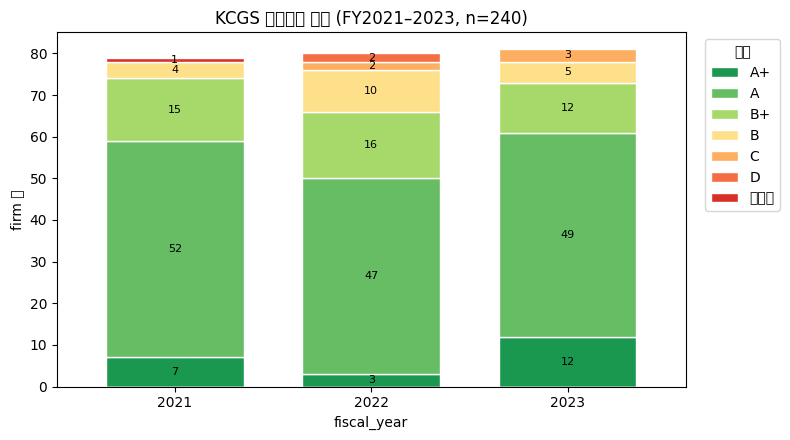

In [6]:
# ---- 등급 분포 시각화 (stacked bar) ----
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#1a9850','#66bd63','#a6d96a','#fee08b','#fdae61','#f46d43','#d73027','#bdbdbd']
dist.plot(kind='bar', stacked=True, ax=ax,
          color=colors[:dist.shape[1]], edgecolor='white', width=0.7)
ax.set_title('KCGS 통합등급 분포 (FY2021–2023, n=240)', fontsize=12)
ax.set_xlabel('fiscal_year')
ax.set_ylabel('firm 수')
ax.legend(title='등급', bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for c in ax.containers:
    ax.bar_label(c, label_type='center', fontsize=8,
                 labels=[f'{int(v)}' if v>0 else '' for v in c.datavalues])
plt.tight_layout()
plt.show()

**그래프 해석:**

- 세 연도 모두 "A가 절반 이상, 그 위·아래 등급이 양쪽 꼬리" 모양으로 거의 일정.
- 2022년에 C·D 등급이 4건 등장 — 단년도 사건일 수 있으므로 회귀 결과를 볼 때 이 4건의 영향력을 별도 확인해야 한다.
- 2023년에 A+가 12건으로 증가 — KCGS 평가기준 변화 가능성(메타데이터에서 확인 필요).

---

## 6. DART × KCGS 결합 — firm-year join 검증

두 데이터를 결합하는 키는 항상 `[stock_code, fiscal_year]`다.  
**`corp_name`(기업명) 으로는 절대 join 하지 않는다.** 
이유:

- 띄어쓰기, 한글/영문 표기, 법인 변경 등으로 같은 기업이 다른 이름으로 표기되는 경우가 빈번.
- 같은 이름의 자회사/모회사가 분리되어 있을 수 있음.
- stock_code는 KRX가 부여한 영구 식별자라 가장 안전.

In [7]:
# ---- DART × KCGS firm-year 매칭 검증 ----
col_keys  = set(zip(collected['stock_code'], collected['fiscal_year'].astype(str)))
kcgs_keys = set(zip(kcgs['stock_code'], kcgs['fiscal_year'].astype(str)))

match = col_keys & kcgs_keys
dart_only = col_keys - kcgs_keys
kcgs_only = kcgs_keys - col_keys

summary = pd.DataFrame({
    '구분': ['DART 총 firm-year', 'KCGS 총 firm-year',
           '교집합 (분석에 들어감)', 'DART에만 있음', 'KCGS에만 있음'],
    '건수': [len(col_keys), len(kcgs_keys), len(match), len(dart_only), len(kcgs_only)],
})
print(summary.to_string(index=False))

print('\n[DART에만 있는 3건 — KCGS 등급 부재]')
for sc, fy in sorted(dart_only):
    name = collected[collected['stock_code']==sc]['corp_name'].iloc[0]
    print(f'  - {sc} {name} FY{fy}')

              구분  건수
DART 총 firm-year 243
KCGS 총 firm-year 240
   교집합 (분석에 들어감) 240
       DART에만 있음   3
       KCGS에만 있음   0

[DART에만 있는 3건 — KCGS 등급 부재]
  - 326030 에스케이바이오팜 FY2021
  - 377300 카카오페이 FY2021
  - 377300 카카오페이 FY2022


### 6.1 누락의 "이유 있는" 해석

| 누락 firm-year | 사유 |
|---|---|
| **326030 에스케이바이오팜 FY2021** | 2020년 7월 상장. KCGS 평가 대상 진입이 늦음. |
| **377300 카카오페이 FY2021** | 2021년 11월 상장. 1차 평가 미포함. |
| **377300 카카오페이 FY2022** | 상장 1년차로 KCGS 평가 사이클이 안 맞음. |

이 3건은 "수집 실패"가 *아니라* "KCGS의 평가 자체가 부재"한 경우다.  
프로젝트 원칙에 따라 **0으로 채우지도, 임의 등급을 부여하지도 않는다.** 단순히 inner join으로 제외하고, 사유를 기록한다.

최종 분석 단위: **240 firm-year** (= 243 − 3).

이 외에 KCGS "미공개" 1건(SK이노베이션 FY2021)은 행으로는 존재하지만 등급 값이 결측이므로 통계 단계에서 제외된다. **즉 회귀 단계에서는 최대 239 firm-year까지 줄어들 수 있음.** 이걸 처음부터 표시해두지 않으면 나중에 "n이 왜 줄었지?"라는 혼란이 생긴다.

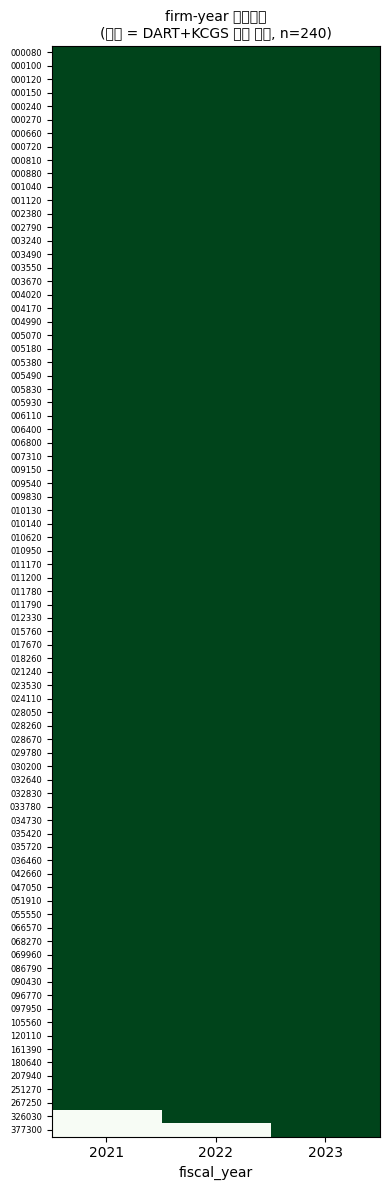

In [8]:
# ---- firm-year 커버리지 히트맵 (시각화) ----
# 행: stock_code (81개), 열: fiscal_year(3개), 값: DART/KCGS 모두 있으면 1
cov = pd.DataFrame(0, 
                    index=sorted(collected['stock_code'].unique()),
                    columns=[2021, 2022, 2023], dtype=int)
for sc, fy in match:
    cov.loc[sc, int(fy)] = 1

fig, ax = plt.subplots(figsize=(4, 12))
ax.imshow(cov.values, aspect='auto', cmap='Greens', vmin=0, vmax=1)
ax.set_xticks(range(3)); ax.set_xticklabels(cov.columns)
ax.set_yticks(range(len(cov))); ax.set_yticklabels(cov.index, fontsize=6)
ax.set_title(f'firm-year 커버리지\n(녹색 = DART+KCGS 모두 있음, n={cov.values.sum()})', fontsize=10)
ax.set_xlabel('fiscal_year')
plt.tight_layout()
plt.show()

히트맵에서 두 줄이 거의 비어 있는 곳이 바로 위의 두 신규 상장 firm(`326030`, `377300`)이다.

---

## 7. fiscal_year vs esg_year — 1년 misalignment 함정

여러 식별자만큼이나 헷갈리는 것이 **"어느 연도"** 의 정의다.

| 용어 | 정의 | 예 |
|---|---|---|
| `fiscal_year` | 사업보고서가 다루는 회계연도 | 2022 |
| `esg_year`    | 사업보고서가 *제출*된 연도, KCGS 등급도 같은 해 발표 | 2023 |
| 관계 | `esg_year = fiscal_year + 1` | |

**왜 fiscal_year로 join 하는가?**

- KCGS 등급은 *회계연도 활동*을 평가한다(2022년 KCGS "등급"은 2022년 사업 활동을 본 것).
- 따라서 DART의 *2022 사업보고서* 와 KCGS의 *fiscal_year=2022 등급* 이 같은 사건을 가리킨다.
- esg_year(제출연도)로 join하면 한 칸씩 밀려 시간 정렬이 어긋난다.

### Decision Box — fiscal_year join vs esg_year join

- **대안:** esg_year로 join (제출연도 = 평가연도).
- **선택:** fiscal_year로 join.
- **근거:** 양쪽 데이터 모두 "평가 대상이 된 활동의 연도"를 가리키도록 정렬.
- **한계:** KCGS 등급 발표 시점과 사업보고서 제출 시점에 작은 차이(수 개월)가 있다. 인과 해석을 한다면 이 시간 차를 명시해야 한다(본 연구는 인과 주장 안 함).

---

## 8. 산업(섹터) 분포 — 표본 대표성 점검

본 ingest 파이프라인은 *현재 산업 분류를 lineage에 포함하지 않는다*.  
이건 의도된 단순화이고, 동시에 **명확한 한계**다.

- DART `corpCode.xml`은 산업분류를 포함하지 않는다.
- 산업분류는 DART `companyAPI` 의 `induty_code`(KSIC) 호출이 별도로 필요.
- 외부에서 받은 `company_master.csv` 와 매칭하면 일부(약 20개) firm은 보강 가능하지만, 81개 전체 커버는 추가 작업이 필요.

아래는 *현재 가용한 범위*에서의 산업 분포 — 부분 데이터임을 명심.

In [9]:
# ---- 외부 company_master에서 산업 정보 부분 결합 ----
# 윈도우 / 맥 / 리눅스 (Cowork mount) 어느 환경에서도 동작하도록 후보 경로를 시도.
import os
candidate_paths = [
    r'C:/Users/jiwoo/OneDrive/obsidian/비정형 데이터 처리/ESG_DART_Project/company_master.csv',
    r'C:\\Users\\jiwoo\\OneDrive\\obsidian\\비정형 데이터 처리\\ESG_DART_Project\\company_master.csv',
    '/sessions/kind-nifty-pascal/mnt/비정형 데이터 처리/ESG_DART_Project/company_master.csv',
    '../비정형 데이터 처리/ESG_DART_Project/company_master.csv',
    '../ESG_DART_Project/company_master.csv',
]
master = None
for p in candidate_paths:
    if os.path.exists(p):
        master = pd.read_csv(p, dtype=str)
        master['stock_code'] = master['stock_code'].str.zfill(6)
        print(f'산업 마스터 로드: {p}')
        break

if master is None:
    print('⚠️ company_master.csv 위치를 찾지 못함 — 이 셀은 스킵해도 무방.')
    print('   (사용자 환경에서 직접 열어볼 때만 경로를 추가하면 됨)')
else:
    ind = master[['stock_code','industry']].drop_duplicates()
    sample_firms = pd.read_csv('sample_firms_expanded.csv', dtype=str)
    sample_firms['stock_code'] = sample_firms['stock_code'].str.zfill(6)
    joined = sample_firms.merge(ind, on='stock_code', how='left')
    matched = joined['industry'].notna().sum()
    print(f'산업 매칭 가능: {matched} / {len(joined)} firms')
    print()
    print('[부분 산업 분포]')
    print(joined['industry'].value_counts())

산업 마스터 로드: /sessions/kind-nifty-pascal/mnt/비정형 데이터 처리/ESG_DART_Project/company_master.csv
산업 매칭 가능: 20 / 81 firms

[부분 산업 분포]
industry
금융지주       3
화학         2
인터넷/플랫폼    2
물류         1
철강         1
반도체        1
지주회사       1
자동차        1
정유         1
비철금속       1
전기전자       1
IT서비스      1
은행         1
바이오의약품     1
에너지/화학     1
식품         1
Name: count, dtype: int64


### 8.1 해석

- 외부 master로 잡히는 산업은 부분이지만, **반도체·자동차·금융·화학·플랫폼** 등 KOSPI 대표 산업이 골고루 포함됨을 알 수 있다.
- 향후 단계에서 `induty_code`를 보강하면 산업 고정효과(industry FE)를 회귀에 포함시킬 수 있다.
- 본 단계에서는 "산업 다양성은 어느 정도 확보돼 보이지만, 산업 통제 변수는 아직 없음" 으로 기록.

### Decision Box — 산업 정보 보강 시점

- **대안:** ingest 단계에서 산업 정보까지 같이 가져온다.
- **선택:** 본 단계에서는 가져오지 않고, 회귀 단계 직전에 별도 보강 모듈로 분리.
- **근거:** 산업 분류는 분석 *선택사항*이고, ingest를 단순하게 유지하면 디버깅이 쉽다.
- **한계:** 산업이 ESG 언어량의 강한 confounder일 수 있어, 보강을 너무 늦추면 검정력이 떨어질 수 있다.

---

## 9. lineage(데이터 계보)를 보존한다는 것

이 노트북에서 가장 중요한 한 개념을 강조하면 **lineage** 다.  
lineage란 "이 행이 어디서 어떻게 만들어졌는지"를 *역으로 따라갈 수 있는 상태*를 유지하는 것이다.

구체적으로 본 프로젝트는 모든 firm-year 행이 다음 5개 ID를 항상 들고 다닌다.

```
stock_code   ── KRX/KCGS와 연결되는 외부 식별자
corp_code    ── DART API 재호출 시 필요
rcept_no     ── 정확히 어떤 ZIP을 받았는지 추적
fiscal_year  ── 회계연도 (분석 시점)
esg_year     ── 제출/평가 연도 (보고 시점)
```

왜 이게 중요한가?

- **재현성:** 누가 와도 stock_code + fiscal_year만 있으면 원본 보고서까지 거꾸로 도달할 수 있다.
- **디버깅:** 회귀에서 이상한 outlier가 나오면 rcept_no로 원문 텍스트를 즉시 다시 볼 수 있다.
- **무결성:** 중간 단계의 transformation 버그가 lineage를 깨지 않는 한 결과를 신뢰할 수 있다.
- **편향 설명:** 실패한 행을 0으로 채우는 대신 *왜* 빠졌는지 sources를 남겨두면 결과의 한계를 정확히 기술할 수 있다.

### 실패 행 처리 원칙

- DART에서 ZIP을 못 받은 firm-year → `failed_logs.csv` 에 사유(`error_type`, `error_msg`)를 기록.
- KCGS 등급이 없는 firm-year → join에서 자연 제외, 본 노트북 6.1에 사유를 명시.
- KCGS 등급이 "미공개" → 값으로 보존하되 회귀에서 결측 처리.

**절대 하지 않는 것:** 등급 = "평균값"으로 채우기, 보고서 = "빈 문자열"로 채우기.

In [10]:
# ---- lineage가 보존된 최종 firm-year 키 ----
# 분석 단위 = (stock_code, fiscal_year)
# 이 셀은 "여기까지가 ingest 단계의 출력"임을 명시한다.

_col = collected.copy()
_col['fiscal_year'] = _col['fiscal_year'].astype(int)
_kcgs = kcgs[['stock_code','fiscal_year','kcgs_grade','kcgs_grade_7','kcgs_grade_4']].copy()
lineage = _col.merge(_kcgs, on=['stock_code','fiscal_year'], how='inner')

lineage_view = lineage[[
    'stock_code','corp_code','corp_name','fiscal_year','esg_year',
    'rcept_no','report_date','kcgs_grade','kcgs_grade_7','kcgs_grade_4'
]]
print(f'최종 firm-year 단위: {len(lineage_view)} 건')
lineage_view.head(8)

최종 firm-year 단위: 240 건


,stock_code,corp_code,corp_name,fiscal_year,esg_year,rcept_no,report_date,kcgs_grade,kcgs_grade_7,kcgs_grade_4
0,000080,00150244,하이트진로,2021,2022,20220317000772,20220317,B+,4.0,2.0
1,000080,00150244,하이트진로,2022,2023,20230316001349,20230316,B,3.0,2.0
2,000080,00150244,하이트진로,2023,2024,20240314000553,20240314,B,3.0,2.0
3,000100,00145109,유한양행,2021,2022,20220310001178,20220310,B+,4.0,2.0
4,000100,00145109,유한양행,2022,2023,20230315001431,20230315,B+,4.0,2.0
5,000100,00145109,유한양행,2023,2024,20240307000960,20240307,A,5.0,3.0
6,000120,00113410,CJ대한통운,2021,2022,20220318000927,20220318,A,5.0,3.0
7,000120,00113410,CJ대한통운,2022,2023,20230317000857,20230317,B+,4.0,2.0


---

## 10. Fix History — 이 파이프라인이 거쳐온 수정 이력

처음 보는 팀원을 위해, ingest 단계에서 실제로 발생했던 *함정과 그 수정* 을 기록한다.

| 시점 | 증상 | 원인 | 수정 |
|---|---|---|---|
| 초기 | corp_code 조회 시 일부 firm 실패 | `pd.read_xml` 이 "00126380" 같은 앞자리 0을 int로 읽어 `126380` 으로 변환 | `dtype=str` 강제 + `zfill(8)` |
| 수집 1차 | 같은 firm·연도에 보고서가 여러 건 (정정공시) | DART는 정정공시도 별개 rcept_no로 발급 | `pick_latest_report()` — `rcept_dt` 내림차순 정렬 후 최신 1건만 사용 |
| 수집 2차 | rate limit 오류 | 연속 요청 간 지연 부재 | `REQUEST_DELAY = 0.5s` + 재시도 시 지수적 대기 |
| KCGS 결합 | 카카오페이/SK바이오팜 매칭 실패 | 신규 상장 firm, KCGS 평가 부재 | inner join + 사유 기록(섹션 6.1) |
| KCGS 정리 | SK이노베이션 FY2021 "미공개" | KCGS가 등급을 게시하지 않음 | 행은 유지, 값은 NaN |
| 구조 변경 | sample_firms.csv (10개) → sample_firms_expanded.csv (81개) | 표본 검정력 부족 | `collect_expanded.py`로 신규 71개만 추가 수집, 기존 zip은 캐시 재사용 |

이 표는 곧 "이 코드를 다시 짤 때 절대 다시 만들지 말아야 할 버그 리스트"이기도 하다.

---

## 11. 다음 단계로의 연결

ingest 단계의 산출물 `(stock_code, fiscal_year)` firm-year 인덱스는 다음 단계들의 *입력*이 된다.

```
 00_ingest (이 노트북)
      │  firm-year × rcept_no × KCGS 등급
      ▼
 01_section_extract   ── II / IV / VI 섹션만 추출 (firm-year당 텍스트 3덩어리)
      ▼
 02_passage_filter    ── ESG seed 단어를 포함한 문장만 남김
      ▼
 03_preprocess        ── 형태소 분석 · 사용자 사전 · stopword 처리
      ▼
 04_feature_build     ── TF-IDF, cosine similarity, 사전 매칭 점수 등
      ▼
 05_merge_for_stats   ── feature × KCGS 등급 결합 (06_analysis 입력)
      ▼
 06_analysis          ── Spearman, OLS, Ordered Logit
```

이미 작성된 기존 노트북들과의 연결:

- `notebooks/01_token_inspection.ipynb` — 토큰화 결과 점검
- `notebooks/02_preprocessing_eval.ipynb` — 전처리 실험 비교
- `notebooks/03_external_validation.ipynb` — KCGS와의 외부 검증(Spearman)
- 보조 문서: `VALIDATION_WORKFLOW.md`, `전처리_설계_분석.md`, `전처리결과_비판적분석.md`

그리고 본 노트북과 짝을 이루는 발표용 요약: **`00_ingest_report.md`** (같은 폴더 또는 프로젝트 루트).

---

## 12. 한 페이지 요약 (발표 슬라이드용)

| 항목 | 값 / 결정 |
|---|---|
| 분석 단위 | **firm × fiscal_year** |
| 표본 | KOSPI 81개 기업 × FY2021–2023 |
| 수집된 DART 사업보고서 | **243건** (failed 0) |
| KCGS 등급 데이터 | 240건 (미공개 1, 누락 3 = 신규 상장) |
| **최종 firm-year (analysis ready)** | **240건** (회귀에서는 미공개 제외 시 239) |
| Join key | `[stock_code, fiscal_year]` (corp_name 절대 사용 금지) |
| 등급 인코딩 | 7단계(S=7…D=1) + 4단계(상위/중상/중하/하위) 동시 보존 |
| 등급 분포 | A=148, B+=43, A+=22, B=19, C=5, D=2, S=0 |
| 산업 분포 | 부분 정보(20/81). 보강은 다음 단계 |
| 핵심 원칙 | lineage 보존, 0-fill 금지, 실패 사유 기록 |

> 이 표 한 장이면 "우리가 무엇을 분석 단위로 삼고 있는가"가 끝난다.  
> 이후 등장하는 모든 ρ, β, p-value는 이 240행 위에서의 통계임을 잊지 말 것.

---

# 01 · 토큰 검사 (Token Inspection)

In [1]:
# 01_token_inspection.ipynb 에 추가할 검증 셀
import sys; sys.path.insert(0, '..')
from src.passage_filter import sentence_density_filter, _split_korean_sentences
import config, pandas as pd

# firm_year_documents.csv에서 샘플 문단 가져오기
docs = pd.read_csv(config.FIRM_YEAR_DOC_PATH, dtype=str)
sample_doc = docs.iloc[0]["document"]
sample_para = sample_doc.split("\n\n")[2]  # 3번째 문단

print("=== 원본 문단 ===")
print(sample_para)
print("\n=== 분리된 문장 ===")
for i, s in enumerate(_split_korean_sentences(sample_para)):
    print(f"  [{i}] {s}")
print("\n=== sentence filter 후 ===")
filtered = sentence_density_filter(sample_para, config.ALL_SEEDS)
print(filtered)

=== 원본 문단 ===
주 관련 자세한 사항은 'VII. 주주에 관한 사항'을 참조하시기 바랍니다.

=== 분리된 문장 ===
  [0] 주 관련 자세한 사항은 'VII. 주주에 관한 사항'을 참조하시기 바랍니다.

=== sentence filter 후 ===
("주 관련 자세한 사항은 'VII. 주주에 관한 사항'을 참조하시기 바랍니다.", [{'is_g_protected': False, 'esg_hit': 1, 'g_hit': 0, 'generic_hit': 0, 'finance_hit': 0, 'length': 42, 'esg_density': 2.381, 'signal_density': 2.381, 'generic_density': 0.0, 'finance_density': 0.0}])


In [2]:
import os, sys
import pandas as pd
from collections import Counter

# notebooks/ 에서 프로젝트 루트(src/, config.py)에 접근하기 위한 경로 설정
sys.path.insert(0, os.path.join(os.getcwd(), '..'))
import config

PREPROC_DIR = config.PREPROC_DIR
print(f"데이터 경로: {PREPROC_DIR}")

# 존재하는 tokenized CSV 확인
available = [
    f.replace('tokenized_', '').replace('.csv', '')
    for f in os.listdir(PREPROC_DIR)
    if f.startswith('tokenized_') and f.endswith('.csv')
]
print(f"사용 가능한 실험: {sorted(available)}")

데이터 경로: c:\projects\esg_dart\data\04_preprocessed
사용 가능한 실험: ['exp_A', 'exp_B', 'exp_C', 'exp_D', 'exp_E', 'exp_F']


In [3]:
# ============================================================
# Taxonomy 분류 사전 (token_classifier.py 결과 반영)
# 이 사전이 색상 분류의 기준이다.
# ============================================================

G_SIGNAL = {
    '이사', '감사', '이사회', '준법', '이해관계자',
    '사외이사', '감사위원회', '위원회', '지배구조',
    '내부통제', '컴플라이언스', '투명성', '주주',
}

ESG_SIGNAL = {
    '온실가스', '탄소중립', '탄소', '탄소배출', '탄소발자국',
    '안전보건', '안전', '보건', '임직원', '고용', '다양성', '인권', '노동',
    '재생에너지', '태양광', '풍력', '수소', '폐기물', '오염', '생태계',
    '공급망', '협력사', '사회공헌', '지역사회',
    '배출량', '감축', '저감', '친환경', '기후변화', '기후', '순환경제',
}

BOILERPLATE = {
    '재무제표', '부채', '차입금', '자본금', '사채', '배당금',
    '원리금', '특수관계인', '당기순이익', '이자비용', '충당금',
    '매출액', '손익', '부채비율', '회사채', '원가',
    '연결재무제표', '연결', '주석', '장부', '회계',
    '정관', '의결권', '의결', '결의', '등기', '법인세',
}

def classify(token):
    if token in G_SIGNAL:     return 'G_SIGNAL'
    if token in ESG_SIGNAL:   return 'ESG_SIGNAL'
    if token in BOILERPLATE:  return 'BOILERPLATE'
    return 'OTHER'

CAT_COLORS = {
    'G_SIGNAL':    'background-color: #cce5ff; color: #003366; font-weight: bold',
    'ESG_SIGNAL':  'background-color: #d4edda; color: #155724; font-weight: bold',
    'BOILERPLATE': 'background-color: #f8d7da; color: #721c24',
    'OTHER':       'background-color: #f8f9fa; color: #6c757d',
}
print('분류 사전 로드 완료')
print(f'  G_SIGNAL: {len(G_SIGNAL)}개 / ESG_SIGNAL: {len(ESG_SIGNAL)}개 / BOILERPLATE: {len(BOILERPLATE)}개')

분류 사전 로드 완료
  G_SIGNAL: 13개 / ESG_SIGNAL: 31개 / BOILERPLATE: 27개


In [4]:
# ============================================================
# 데이터 로드 함수
# ============================================================

def load_experiment(exp_id):
    path = os.path.join(PREPROC_DIR, f'tokenized_{exp_id}.csv')
    if not os.path.exists(path):
        raise FileNotFoundError(f'{path} 없음')
    df = pd.read_csv(path, dtype=str)
    df['token_count'] = pd.to_numeric(df['token_count'], errors='coerce').fillna(0)
    print(f'[{exp_id}] {len(df)}개 firm-year 로드 / '
          f'평균 토큰: {df["token_count"].mean():.1f}')
    return df

def get_token_counter(df):
    tokens = []
    for t in df['joined_text'].fillna(''):
        tokens.extend(t.split())
    return Counter(tokens)

# 비교할 실험 목록 — 존재하는 것만 로드
EXPS_TO_COMPARE = ['exp_B', 'exp_E', 'exp_F']

data = {}
counters = {}
for exp_id in EXPS_TO_COMPARE:
    try:
        data[exp_id] = load_experiment(exp_id)
        counters[exp_id] = get_token_counter(data[exp_id])
    except FileNotFoundError as e:
        print(f'[SKIP] {e}')

[exp_B] 30개 firm-year 로드 / 평균 토큰: 11169.7
[exp_E] 30개 firm-year 로드 / 평균 토큰: 8773.8
[exp_F] 30개 firm-year 로드 / 평균 토큰: 8773.6


---
## 1. Top-50 Token 분류표 — 직접 읽어볼 것

아래 표를 읽는 방법:
- **빨간 행이 상위권에 많으면**: 재무 boilerplate contamination이 심각하다.
- **파란 행이 빠져 있으면**: G-signal이 소실된 것 → 해당 실험은 G 분석에 사용 불가.
- **초록 행이 늘어나면**: ESG specificity가 개선된 것.

> ⚠️ 순위(rank)가 낮은 초록/파란 토큰도 중요하다.
> TF-IDF는 상위 빈도 토큰보다 **기업 간 변별력**이 있는 토큰에 가중치를 준다.

In [5]:
from IPython.display import display, HTML

def build_token_table(counter, top_n=50, exp_id=''):
    rows = []
    for rank, (token, count) in enumerate(counter.most_common(top_n), 1):
        cat = classify(token)
        rows.append({'rank': rank, 'token': token, 'count': count, 'category': cat})
    df = pd.DataFrame(rows)
    return df

def style_table(df):
    def row_style(row):
        style = CAT_COLORS.get(row['category'], '')
        return [style] * len(row)
    styled = df.style.apply(row_style, axis=1)
    styled = styled.set_caption(f'Top-{len(df)} Tokens')
    styled = styled.set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#343a40'), ('color', 'white'),
                  ('font-size', '12px'), ('padding', '6px')]
    }, {
        'selector': 'td',
        'props': [('font-size', '13px'), ('padding', '4px 10px')]
    }])
    return styled

# 실험별 Top-50 출력
for exp_id, counter in counters.items():
    print(f'\n{'='*60}')
    print(f'  {exp_id}  (총 unique token: {len(counter):,}개)')
    print(f'{'='*60}')
    tbl = build_token_table(counter, top_n=50, exp_id=exp_id)
    display(style_table(tbl))


  exp_B  (총 unique token: 7,048개)


,rank,token,count,category
0,1,주주,3921,G_SIGNAL
1,2,기준,3038,OTHER
2,3,이사,2943,G_SIGNAL
3,4,감사,2903,G_SIGNAL
4,5,환경,2515,OTHER
5,6,이사회,2482,G_SIGNAL
6,7,공시,2475,OTHER
7,8,회계,2378,BOILERPLATE
8,9,위원회,2327,G_SIGNAL
9,10,연결,2245,BOILERPLATE



  exp_E  (총 unique token: 6,780개)


,rank,token,count,category
0,1,주주,3368,G_SIGNAL
1,2,감사,2760,G_SIGNAL
2,3,이사,2732,G_SIGNAL
3,4,환경,2400,OTHER
4,5,이사회,2305,G_SIGNAL
5,6,위원회,2194,G_SIGNAL
6,7,공시,2171,OTHER
7,8,에너지,2003,OTHER
8,9,가치,1853,OTHER
9,10,공정,1792,OTHER



  exp_F  (총 unique token: 6,784개)


,rank,token,count,category
0,1,주주,3368,G_SIGNAL
1,2,감사,2760,G_SIGNAL
2,3,이사,2732,G_SIGNAL
3,4,환경,2400,OTHER
4,5,이사회,2305,G_SIGNAL
5,6,위원회,2194,G_SIGNAL
6,7,공시,2171,OTHER
7,8,에너지,2004,OTHER
8,9,가치,1853,OTHER
9,10,공정,1792,OTHER


---
## 2. Boilerplate Contamination 패턴

BOILERPLATE 분류 토큰만 따로 뽑아서 **얼마나, 어떤 것들이** 등장하는지 확인한다.

이 분석의 목적:
- 어떤 재무 단어가 가장 자주 나오는지 순위를 확인
- exp_E/F에서 이 단어들이 실제로 줄었는지 비교
- 패턴을 보고 추가 제거가 필요한 단어를 식별

BOILERPLATE 토큰 출현 빈도 비교 (총 횟수)
──────────────────────────────────────────────────


,exp_B,exp_E,exp_F
boilerplate_token,,,
회계,"2,378",0,0
연결,"2,245",0,0
재무제표,"1,681",0,0
부채,"1,442",0,0
결의,"1,109",0,0
의결,673,0,0
손익,361,0,0
장부,355,0,0
원가,353,0,0


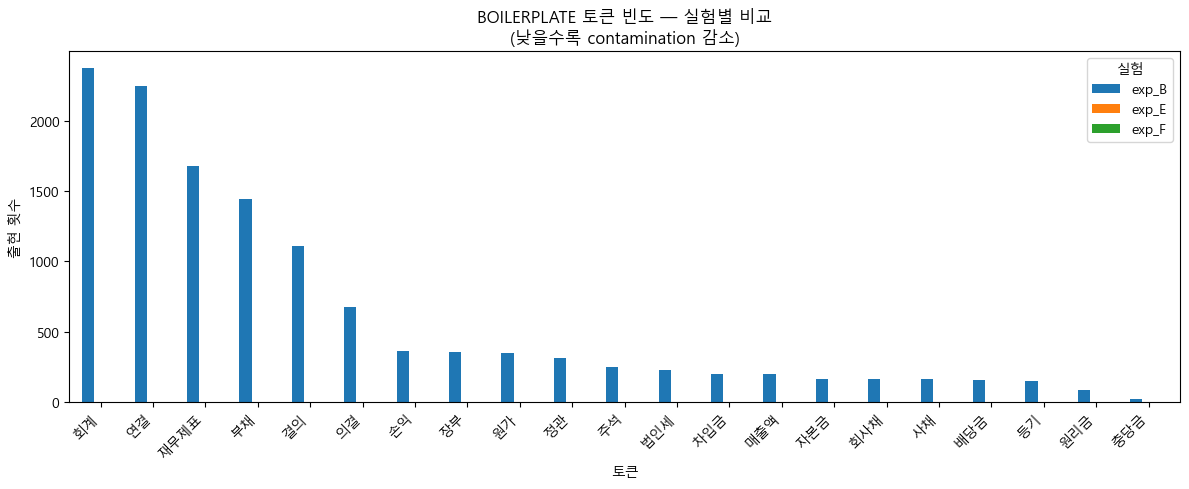

In [6]:
import matplotlib.pyplot as plt
import matplotlib
try:
    matplotlib.rc('font', family='Malgun Gothic')
except:
    pass
plt.rcParams['axes.unicode_minus'] = False

def get_bp_breakdown(counter):
    """BOILERPLATE 토큰 빈도 딕셔너리 반환"""
    return {t: counter[t] for t in BOILERPLATE if counter[t] > 0}

# 각 실험별 BOILERPLATE 토큰 빈도
bp_data = {exp_id: get_bp_breakdown(counter)
           for exp_id, counter in counters.items()}

# 출현한 BOILERPLATE 토큰 전체 union
all_bp_tokens = sorted(
    set().union(*[set(d.keys()) for d in bp_data.values()]),
    key=lambda t: max(d.get(t, 0) for d in bp_data.values()),
    reverse=True
)

if all_bp_tokens:
    bp_df = pd.DataFrame(
        {exp_id: [bp_data[exp_id].get(t, 0) for t in all_bp_tokens]
         for exp_id in counters},
        index=all_bp_tokens
    )
    bp_df.index.name = 'boilerplate_token'

    print('BOILERPLATE 토큰 출현 빈도 비교 (총 횟수)')
    print('─' * 50)
    display(bp_df.style
        .background_gradient(cmap='Reds', axis=None)
        .format('{:,}'))

    # 시각화
    fig, ax = plt.subplots(figsize=(12, 5))
    bp_df.plot(kind='bar', ax=ax, width=0.7)
    ax.set_title('BOILERPLATE 토큰 빈도 — 실험별 비교\n(낮을수록 contamination 감소)')
    ax.set_xlabel('토큰')
    ax.set_ylabel('출현 횟수')
    ax.legend(title='실험')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print('BOILERPLATE 토큰이 발견되지 않았습니다.')
    print('→ exp_E/F의 BOILERPLATE_NOUNS 필터가 잘 작동하고 있을 가능성이 높습니다.')

---
## 3. G-Signal 보존 확인 ← 가장 중요한 검증

G_SIGNAL 토큰이 vocabulary에 살아 있는지 확인한다.

**판단 기준:**
- ✅ 모든 G_SIGNAL 토큰이 vocabulary에 있음 → 보존됨
- ⚠️ 일부 누락 → 해당 실험의 G-domain 피처가 약해짐
- ❌ 절반 이상 누락 → 해당 실험으로 G 상관분석 불가

> 주의: vocabulary 존재만으로는 부족하다.
> **출현 빈도**도 함께 확인해야 한다 — 너무 드물게 나오면 피처 signal이 약해진다.

In [7]:
print('G_SIGNAL 토큰 보존 상태\n' + '='*60)

g_status_rows = []
for g_token in sorted(G_SIGNAL):
    row = {'token': g_token}
    for exp_id, counter in counters.items():
        cnt = counter.get(g_token, 0)
        row[exp_id] = cnt
    row['status'] = '✅' if all(
        counter.get(g_token, 0) > 0 for counter in counters.values()
    ) else '⚠️ 일부 누락'
    g_status_rows.append(row)

g_df = pd.DataFrame(g_status_rows).set_index('token')

def highlight_zero(val):
    if isinstance(val, (int, float)) and val == 0:
        return 'background-color: #ff6b6b; color: white; font-weight: bold'
    elif isinstance(val, (int, float)) and val > 0:
        return 'background-color: #d4edda'
    return ''

exp_cols = [c for c in g_df.columns if c.startswith('exp_')]

display(g_df.style
    .map(highlight_zero, subset=exp_cols)
    .format({c: '{:,}' for c in exp_cols})
    .set_caption('G_SIGNAL 토큰별 출현 횟수 (0 = 소실 → 빨간색)'))

# 요약
print()
for exp_id in counters:
    present = sum(1 for t in G_SIGNAL if counters[exp_id].get(t, 0) > 0)
    pct = present / len(G_SIGNAL) * 100
    status = '✅' if pct == 100 else ('⚠️' if pct >= 80 else '❌')
    print(f'  {exp_id}: {present}/{len(G_SIGNAL)}개 보존 ({pct:.0f}%) {status}')

G_SIGNAL 토큰 보존 상태


,exp_B,exp_E,exp_F,status
token,,,,
감사,"2,903","2,760","2,760",✅
감사위원회,0,0,0,⚠️ 일부 누락
내부통제,2,2,2,✅
사외이사,97,91,91,✅
위원회,"2,327","2,194","2,194",✅
이사,"2,943","2,732","2,732",✅
이사회,"2,482","2,305","2,305",✅
이해관계자,212,200,200,✅
주주,"3,921","3,368","3,368",✅



  exp_B: 9/13개 보존 (69%) ❌
  exp_E: 9/13개 보존 (69%) ❌
  exp_F: 9/13개 보존 (69%) ❌


---
## 4. 실험 간 Top-30 Side-by-Side 비교

exp_B(baseline)와 exp_E/F를 나란히 놓고 무엇이 바뀌었는지 직접 읽는다.

**읽는 방법:**
- 같은 순위에서 빨간→초록/파란으로 바뀌면: specificity 개선
- 상위권에서 빨간 토큰이 사라졌으면: contamination 감소
- 파란 토큰이 사라졌으면: G-signal 손실 (위험 신호)

> 이 비교가 04_evaluate_preprocessing.py의 수치보다 더 많은 것을 말해준다.

In [8]:
TOP_N = 30

# Side-by-side DataFrame 생성
comparison_cols = {}
for exp_id, counter in counters.items():
    top_tokens = [token for token, _ in counter.most_common(TOP_N)]
    comparison_cols[f'{exp_id}_token'] = top_tokens
    comparison_cols[f'{exp_id}_cat'] = [classify(t) for t in top_tokens]

comp_df = pd.DataFrame(comparison_cols)
comp_df.index = comp_df.index + 1
comp_df.index.name = 'rank'

def style_comparison(df):
    def cell_style(val):
        return CAT_COLORS.get(val, '')

    cat_cols = [c for c in df.columns if c.endswith('_cat')]
    styled = df.style.map(cell_style, subset=cat_cols)
    styled = styled.set_table_styles([{
        'selector': 'th',
        'props': [('background-color', '#343a40'), ('color', 'white'), ('padding', '6px')]
    }])
    return styled

display(style_comparison(comp_df))

,exp_B_token,exp_B_cat,exp_E_token,exp_E_cat,exp_F_token,exp_F_cat
rank,,,,,,
1,주주,G_SIGNAL,주주,G_SIGNAL,주주,G_SIGNAL
2,기준,OTHER,감사,G_SIGNAL,감사,G_SIGNAL
3,이사,G_SIGNAL,이사,G_SIGNAL,이사,G_SIGNAL
4,감사,G_SIGNAL,환경,OTHER,환경,OTHER
5,환경,OTHER,이사회,G_SIGNAL,이사회,G_SIGNAL
6,이사회,G_SIGNAL,위원회,G_SIGNAL,위원회,G_SIGNAL
7,공시,OTHER,공시,OTHER,공시,OTHER
8,회계,BOILERPLATE,에너지,OTHER,에너지,OTHER
9,위원회,G_SIGNAL,가치,OTHER,가치,OTHER


---
## 5. ESG_SIGNAL 토큰 보존 확인

ESG_SIGNAL 토큰이 실험 간에 얼마나 유지되는지 확인한다.
이 토큰들이 top-30에 오르거나 vocabulary에 있는 것이 측정 타당도의 기반이다.

In [9]:
esg_rows = []
for esg_token in sorted(ESG_SIGNAL):
    row = {'token': esg_token}
    for exp_id, counter in counters.items():
        row[exp_id] = counter.get(esg_token, 0)
    esg_rows.append(row)

esg_df = pd.DataFrame(esg_rows).set_index('token')
exp_cols = [c for c in esg_df.columns if c.startswith('exp_')]

# 총합 기준 정렬
esg_df['_total'] = esg_df[exp_cols].sum(axis=1)
esg_df = esg_df.sort_values('_total', ascending=False).drop(columns=['_total'])

display(esg_df.style
    .background_gradient(cmap='Greens', subset=exp_cols)
    .format({c: '{:,}' for c in exp_cols})
    .set_caption('ESG_SIGNAL 토큰 출현 빈도 (진할수록 많이 등장)'))

# ESG_SIGNAL coverage 요약
print()
for exp_id in exp_cols:
    present = (esg_df[exp_id] > 0).sum()
    pct = present / len(ESG_SIGNAL) * 100
    print(f'  {exp_id}: ESG_SIGNAL {present}/{len(ESG_SIGNAL)}개 출현 ({pct:.0f}%)')

,exp_B,exp_E,exp_F
token,,,
온실가스,709,709,709
안전,699,700,700
탄소,395,395,395
배출량,370,370,370
오염,287,287,287
임직원,260,248,248
기후,209,209,209
보건,207,209,209
풍력,193,193,193



  exp_B: ESG_SIGNAL 22/31개 출현 (71%)
  exp_E: ESG_SIGNAL 21/31개 출현 (68%)
  exp_F: ESG_SIGNAL 21/31개 출현 (68%)


---
## 6. Semantic Shift 확인 — 무엇이 올라왔는가

exp_B에는 없었는데 exp_E/F top-50에 새로 등장한 토큰을 확인한다.
boilerplate가 제거된 자리에 의미 있는 토큰이 올라왔다면 preprocessing 개선이 성공한 것이다.

In [10]:
TOP_N_SHIFT = 50

if 'exp_B' in counters:
    baseline_top = set(t for t, _ in counters['exp_B'].most_common(TOP_N_SHIFT))

    for exp_id in [e for e in counters if e != 'exp_B']:
        target_top = set(t for t, _ in counters[exp_id].most_common(TOP_N_SHIFT))

        new_tokens = target_top - baseline_top
        removed_tokens = baseline_top - target_top

        print(f'\n── exp_B → {exp_id} 변화 (top-{TOP_N_SHIFT} 기준) ──')

        print(f'\n  ▲ 새로 진입한 토큰 ({len(new_tokens)}개):')
        new_classified = sorted([(t, classify(t)) for t in new_tokens],
                                 key=lambda x: counters[exp_id][x[0]], reverse=True)
        for t, cat in new_classified:
            marker = {'G_SIGNAL': '🔵', 'ESG_SIGNAL': '🟢',
                      'BOILERPLATE': '🔴', 'OTHER': '⚪'}.get(cat, '⚪')
            print(f'    {marker} {t:12} ({cat}) freq={counters[exp_id][t]:,}')

        print(f'\n  ▼ 빠진 토큰 ({len(removed_tokens)}개):')
        removed_classified = sorted([(t, classify(t)) for t in removed_tokens],
                                     key=lambda x: counters['exp_B'][x[0]], reverse=True)
        for t, cat in removed_classified:
            marker = {'G_SIGNAL': '🔵', 'ESG_SIGNAL': '🟢',
                      'BOILERPLATE': '🔴', 'OTHER': '⚪'}.get(cat, '⚪')
            print(f'    {marker} {t:12} ({cat}) was={counters["exp_B"][t]:,}')
else:
    print('exp_B가 로드되지 않아 비교할 수 없습니다.')


── exp_B → exp_E 변화 (top-50 기준) ──

  ▲ 새로 진입한 토큰 (14개):
    ⚪ 개발           (OTHER) freq=999
    ⚪ 현황           (OTHER) freq=954
    ⚪ 위원           (OTHER) freq=903
    ⚪ 강화           (OTHER) freq=900
    ⚪ 승인           (OTHER) freq=882
    ⚪ 성장           (OTHER) freq=881
    ⚪ 발생           (OTHER) freq=877
    ⚪ 상품           (OTHER) freq=857
    ⚪ 이행           (OTHER) freq=856
    ⚪ 정기           (OTHER) freq=839
    ⚪ 발행           (OTHER) freq=817
    ⚪ 영업           (OTHER) freq=816
    ⚪ 재무           (OTHER) freq=806
    ⚪ 위험           (OTHER) freq=794

  ▼ 빠진 토큰 (14개):
    ⚪ 기준           (OTHER) was=3,038
    🔴 회계           (BOILERPLATE) was=2,378
    🔴 연결           (BOILERPLATE) was=2,245
    ⚪ 경우           (OTHER) was=1,742
    🔴 재무제표         (BOILERPLATE) was=1,681
    ⚪ 관리           (OTHER) was=1,552
    ⚪ 자산           (OTHER) was=1,525
    ⚪ 기간           (OTHER) was=1,489
    🔴 부채           (BOILERPLATE) was=1,442
    ⚪ 투자           (OTHER) was=1,419
    ⚪ 당기           (OTHER)

---
### Cheap-talk 관점에서 볼 것

top token에 `재무제표 / 부채 / 연결`이 많이 나온다면:
> 기업들이 ESG를 이야기하는 문단에서조차 재무 의무공시 언어가 지배적이다.
> 이것 자체가 ESG 담론이 독립적 의미 공간을 형성하지 못하고 있다는 증거일 수 있다.

`감축 / 탄소중립 / 안전보건`이 상위권에 있다면:
> 기업 간 ESG 표현 밀도가 다를 수 있고, 이것이 KCGS 등급과 연관될 가능성이 있다.

In [14]:
# ============================================================
# [S7] Sentence Density Scoring — Sample Inspection
# 목적: sentence_score()가 실제 ESG 패시지에서 어떻게 동작하는지 확인.
#       pipeline 전체 적용 전에 반드시 눈으로 검증할 것.
# ============================================================

import sys
sys.path.insert(0, "..")
import config
import pandas as pd
from src.passage_filter import (
    _split_korean_sentences,
    sentence_score,
    sentence_density_filter,
    aggregate_passage_features,
)

# firm-year document 로드
docs = pd.read_csv(config.FIRM_YEAR_DOC_PATH, dtype=str)
print(f"총 firm-year: {len(docs)}개")

# 검사할 firm-year 선택 (주요 대기업 우선 확인 권장)
TARGET_STOCK = "005930"  # 삼성전자 (변경 가능)
sample_doc = docs[docs["stock_code"] == TARGET_STOCK].iloc[0]
print(f"\n검사 대상: {sample_doc['stock_code']} FY{sample_doc['fiscal_year']}")

# 패시지 추출
paragraphs = sample_doc["document"].split("\n\n")
print(f"패시지 수: {len(paragraphs)}")

# 각 패시지 검사
for i, para in enumerate(paragraphs[:5]):  # 처음 5개 패시지
    print(f"\n{'='*60}")
    print(f"[패시지 {i}] 원본 ({len(para)}자):")
    print(para[:200] + "..." if len(para) > 200 else para)
    
    sentences = _split_korean_sentences(para)
    print(f"\n  → 분리된 문장 수: {len(sentences)}")
    
    for j, sent in enumerate(sentences):
        sc = sentence_score(sent, config.ALL_SEEDS)
        flag = (
            "🔵G" if sc["is_g_protected"]
            else "🟢E" if sc["esg_hit"] > 0
            else "🔴fin" if sc["finance_hit"] > 0
            else "⚪"
    )
        print(
            f"  [{j}]{flag} "
            f"esg={sc['esg_density']:.2f} "
            f"sig={sc['signal_density']:.2f} "
            f"fin={sc['finance_density']:.2f} | "
            f"{sent[:80]}..."
    )
        
    if sc["finance_density"] > 0:
        print("     🔴 FINANCE RESIDUAL DETECTED")
    
    # 필터 적용 결과
    filtered, scored = sentence_density_filter(para, config.ALL_SEEDS)
    agg = aggregate_passage_features(scored)
    print(f"\n  [필터 후] {len(para)}자 → {len(filtered)}자")

    print(
        f"  mean_esg_density={agg['mean_esg_density']:.4f} "
        f"mean_signal_density={agg['mean_signal_density']:.4f} "
        f"mean_finance_density={agg['mean_finance_density']:.4f}"
    )

if len(filtered) < len(para) * 0.5:
    print("  ⚠️ 50% 이상 제거됨 — 내용 확인 필요!")
    
    # G-signal 보존 확인
    g_original = any(g in para for g in {"이사", "감사", "이사회", "준법"})
    g_filtered = any(g in filtered for g in {"이사", "감사", "이사회", "준법"})
    if g_original and not g_filtered:
        print("  ❌ G-SIGNAL LOSS DETECTED!")
    elif g_original and g_filtered:
        print("  ✅ G-signal 보존 확인")

총 firm-year: 30개

검사 대상: 005930 FY2021
패시지 수: 329

[패시지 0] 원본 (80자):
당사는 1984년 2월 28일 정기주주총회 결의에 의거하여 상호를 &cr      삼성전자공업주식회사에서 삼성전자주식회사로 변경하였습니다.&cr

  → 분리된 문장 수: 1
  [0]🟢E esg=1.25 sig=1.25 fin=1.25 | 당사는 1984년 2월 28일 정기주주총회 결의에 의거하여 상호를 &cr      삼성전자공업주식회사에서 삼성전자주식회사로 변경하였습니다.&cr...
     🔴 FINANCE RESIDUAL DETECTED

  [필터 후] 80자 → 80자
  mean_esg_density=1.2500 mean_signal_density=1.2500 mean_finance_density=1.2500

[패시지 1] 원본 (93자):
※ 소유주식수 및 지분율은 최대주주 및 그 특수관계인의 합산 내역이며, &cr    의결권 있는 주식(기타 법률에 의해 의결권 행사가 제한된 주식도 포함) 기준입니다.

  → 분리된 문장 수: 1
  [0]🟢E esg=1.08 sig=1.08 fin=2.15 | ※ 소유주식수 및 지분율은 최대주주 및 그 특수관계인의 합산 내역이며, &cr    의결권 있는 주식(기타 법률에 의해 의결권 행사가 제한된 주...
     🔴 FINANCE RESIDUAL DETECTED

  [필터 후] 93자 → 93자
  mean_esg_density=1.0753 mean_signal_density=1.0753 mean_finance_density=2.1505

[패시지 2] 원본 (42자):
주 관련 자세한 사항은 'VII. 주주에 관한 사항'을 참조하시기 바랍니다.

  → 분리된 문장 수: 1
  [0]🟢E esg=2.38 sig=2.38 fin=0.00 | 주 관련 자세한 사항은 'VII. 주주에 관한 사항'을 참조하시기 바랍니다....

  [필터 후] 42자 → 42자
  mean_esg_

In [18]:
import pandas as pd
import config
import os

df = pd.read_csv(
    os.path.join(config.PREPROC_DIR, "features_exp_E.csv")
)

print(df.columns.tolist())

['esg_year', 'fiscal_year', 'corp_code', 'stock_code', 'total_tokens', 'esg_signal_count', 'g_signal_count', 'bp_count', 'esg_signal_ratio', 'g_signal_ratio', 'bp_contamination_rate', 'esg_g_relative', 'esg_tfidf_concentration']


In [ ]:
df["esg_tfidf_concentration"].describe()

count    30.000000
mean      0.078457
std       0.025943
min       0.030200
25%       0.055800
50%       0.075000
75%       0.107850
max       0.120300
Name: esg_tfidf_concentration, dtype: float64

<Axes: >

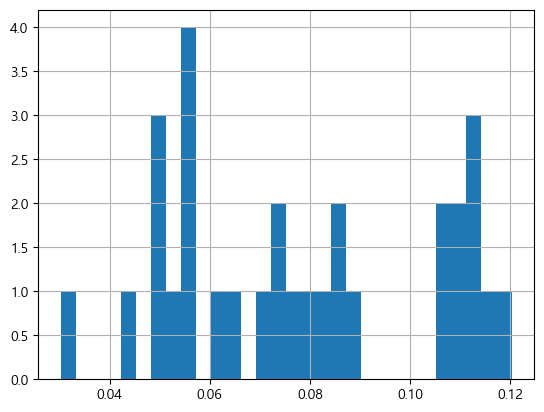

In [20]:
df["esg_tfidf_concentration"].hist(bins=30)

---

# 02 · 전처리 실험 — 설계와 비교 (exp_B / exp_E / exp_F)

## 1. 파이프라인 개요

원시 사업보고서가 firm-year 수준의 ESG feature가 되기까지의 흐름을 그림으로 정리한다.

```
원시 사업보고서 (rcept_no)
    └── II. 사업의 내용
    └── IV. 이사의 경영진단 및 분석의견
    └── VI. 이사회 등 회사의 기관에 관한 사항

        ▼  [1] 회사명 변형 제거
        ▼  [2] 숫자 처리  (exp_E: remove_all / exp_F: keep_quantity)
        ▼  [3] 문장 수준 boilerplate 필터 (exp_E/F)
        ▼  [4] Kiwi 형태소 분석 — 명사(NNG/NNP)만
        ▼  [5] 불용어 제거 (G_SIGNAL 13개는 절대 보호)
        ▼  joined_text  (firm-year 1행)

        ▼  feature_builder
        ▼  features_exp_{B,E,F}.csv
```

### 왜 이 순서인가
- **회사명을 가장 먼저** 제거 → "삼성전기" 같은 firm 식별자가 토큰으로 누설되지 않게.
- **숫자 처리는 형태소 분석 전** → Kiwi가 "30%"를 분해하기 전에 `[NUM]퍼센트`로 잠근다(exp_F).
- **문장 필터도 형태소 분석 전** → "정기주주총회 결의에 의거" 같은 의무공시는 단어가 아니라 *문장 단위*로 잡아야 한다.

### G_SIGNAL 절대 보호 13종
```
이사 / 감사 / 이사회 / 준법 / 이해관계자 /
사외이사 / 감사위원회 / ESG위원회 / 컴플라이언스 /
위원회 / 지배구조 / 투명성 / 내부통제 / 주주
```
이 토큰들은 **어떤 불용어 집합에 들어 있어도** 런타임에 제외된다. KCGS G 등급 핵심 항목과 직결되기 때문이다.


## 2. 환경 셋업 — 산출물 로드

본 notebook은 새로 전처리를 돌리지 않는다. 이미 `03_preprocess_experiment.py`와 `feature_builder.py`로 만든 산출물을 로드하고 *해석*한다.

> 실행 순서를 다시 보고 싶다면: `RUN_TOKEN_CLASSIFIER.md`, `VALIDATION_WORKFLOW.md` 참조.


In [ ]:
import os, sys, json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# 한글 폰트 설정 (Windows 환경 기본)
plt.rcParams['font.family'] = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
mpl.rcParams['figure.dpi'] = 100

PROJ_ROOT = r'C:\projects\esg_dart'
PREPROC   = os.path.join(PROJ_ROOT, 'data', '04_preprocessed')
MERGED    = os.path.join(PROJ_ROOT, 'data', '05_merged')

eval_cmp   = pd.read_csv(os.path.join(PREPROC, 'eval_comparison.csv'))
eval_delta = pd.read_csv(os.path.join(PREPROC, 'eval_delta.csv'))
spearman   = pd.read_csv(os.path.join(PREPROC, 'spearman_results.csv'))

features_B = pd.read_csv(os.path.join(PREPROC, 'features_exp_B.csv'), dtype={'stock_code': str, 'corp_code': str, 'rcept_no': str})
features_E = pd.read_csv(os.path.join(PREPROC, 'features_exp_E.csv'), dtype={'stock_code': str, 'corp_code': str, 'rcept_no': str})
features_F = pd.read_csv(os.path.join(PREPROC, 'features_exp_F.csv'), dtype={'stock_code': str, 'corp_code': str, 'rcept_no': str})

print('산출물 로드 완료')
print(f'  features_B: {features_B.shape}')
print(f'  features_E: {features_E.shape}')
print(f'  features_F: {features_F.shape}')


## 3. 단계별 의사결정 — Decision Box 형식

각 단계는 *대안 → 선택 → 정당화 → 한계*의 4단 구조로 기록한다. 이는 사후 결과를 보고 설정을 바꾸는 p-hacking을 막기 위한 원장이다.

### 3.1 형태소 분석 — Kiwi 선택
- **Alternative**: KoNLPy/Okt, Mecab-ko, Kiwi
- **Choice**: Kiwi
- **Justification**: 한국 사업보고서의 복합 명사("탄소중립", "재생에너지")를 더 정확히 분리. 속도도 빠름. 실패 시 Okt fallback.
- **Limitation**: 도메인 신조어(TCFD, ESG위원회 등)는 사용자 사전 미등록 시 분해될 수 있음 → G_SIGNAL_PROTECT로 일부 보완.

### 3.2 회사명 제거
- **Alternative**: 무시 / 정규식 / NER 기반
- **Choice**: 정규식 + 4가지 변형(`(주)X / X(주) / ㈜X / 주식회사 X`)
- **Justification**: NER은 학습 비용이 큼. 사명 변형은 한정적이라 정규식이 안전.
- **Limitation**: 외국 자회사·약칭은 누락 가능.

### 3.3 숫자 처리 — exp_E vs exp_F 분기점
- **Alternative**: (a) 전부 제거 (remove_all) (b) 단위 결합만 보존 (keep_quantity) (c) 전부 보존
- **Choice**: exp_E는 (a), exp_F는 (b)
- **Justification**: ESG 공시는 "탄소배출 30% 감축"처럼 정량 표현이 본질. 전부 제거하면 "구체적 약속"과 "추상적 수사"의 차이가 사라진다.
- **Limitation**: 단위가 흔한 산업(에너지·소재)이 과대표현될 수 있음.

### 3.4 문장 수준 boilerplate 필터 (exp_E/F)
- **Alternative**: 토큰 단계 제거 / 문장 단계 제거
- **Choice**: 문장 단계 (정규식 18종)
- **Justification**: 같은 토큰("이사회")이 ESG 맥락에서도 등장 → 단어 단위로는 잘라낼 수 없다.
- **Limitation**: 정규식이 너무 강하면 ESG 신호도 함께 제거됨 → 제거된 줄을 모두 로그로 보존.

### 3.5 불용어 집합 강도
- **Alternative**: minimal / standard / extended
- **Choice**: exp_B = standard (pre-reg baseline), exp_E/F = extended + BOILERPLATE_NOUNS
- **Justification**: extended는 G_SIGNAL 보호와 결합되어야만 안전하다. exp_D 실험에서 보호 없이 extended 적용 시 G 피처가 소실됐다.
- **Limitation**: ambiguous 토큰(운영·관리)이 일부 의미 손실 위험 → token_taxonomy 수동 검토로 사후 보정.


## 4. 실험 설계 비교 — 무엇이 다른가

| 실험 | 불용어 | 숫자 처리 | 문장 필터 | 목적 |
|------|--------|-----------|-----------|------|
| exp_A | minimal | remove_all | 없음 | 투명성 기준선 |
| **exp_B** | **standard** | remove_all | 없음 | **pre-reg baseline ★** |
| exp_C | minimal | keep_quantity | 없음 | 수치 보존 효과 |
| exp_D | extended | remove_all | 없음 | 과잉 제거 위험 (G_SIGNAL 소실 관찰) |
| **exp_E** | extended | remove_all | **18개 패턴** | boilerplate 감소 |
| **exp_F** | extended | **keep_quantity** | 18개 패턴 | 최적 설정 — ESG 정량 표현 보존 |

### Decision Box — 왜 exp_F를 만들었는가
| 항목 | 내용 |
|------|------|
| Alternative | exp_E만으로 충분한가? |
| Choice | 아니다 — exp_F 추가 |
| Justification | ESG 공시의 본질은 정량 약속이다. 모든 숫자를 지우면 cheap-talk 검정 자체가 어려워진다. |
| Limitation | exp_F의 효과가 본 표본에서는 매우 작다(top-30 토큰이 거의 동일). 표본 확장에서 차이가 드러날 가능성. |


## 5. 결과 (1) — Density / Vocab 변화

`eval_comparison.csv`의 핵심 수치를 시각화한다. 분석 결과를 보고 전처리 설정을 바꾸지 않기 위해, 이 visualization은 **사후 검증**용이다.

In [ ]:
# eval_comparison 핵심 컬럼 추리기
core = eval_cmp[['exp_id', 'n_docs', 'avg_token_count', 'vocab_size',
                 'tf_bp_rate', 'tf_esg_rate', 'tf_g_rate']].copy()
core.columns = ['실험', '문서수', '평균토큰', 'vocab', 'BP%', 'ESG%', 'G%']
core.set_index('실험')


In [ ]:
# 시각화: token count vs vocab vs BP%
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colors = {'exp_B': '#888888', 'exp_E': '#1f77b4', 'exp_F': '#d62728'}
order = ['exp_B', 'exp_E', 'exp_F']

c = [colors[e] for e in order]
axes[0].bar(order, eval_cmp.set_index('exp_id').loc[order, 'avg_token_count'], color=c)
axes[0].set_title('평균 토큰 수 (firm당)')
axes[0].set_ylabel('avg tokens')

axes[1].bar(order, eval_cmp.set_index('exp_id').loc[order, 'vocab_size'], color=c)
axes[1].set_title('Vocabulary 크기')
axes[1].set_ylabel('unique nouns')

axes[2].bar(order, eval_cmp.set_index('exp_id').loc[order, 'tf_bp_rate'], color=c)
axes[2].set_title('Boilerplate 비율 (TF top-30 중 BP token %)')
axes[2].set_ylabel('% of top-30')
axes[2].set_ylim(0, max(15, eval_cmp['tf_bp_rate'].max()*1.2))

for ax in axes:
    ax.grid(axis='y', alpha=0.3)
fig.suptitle('exp_B → exp_E/F: 토큰은 21% 감소, vocab은 3.8% 감소, boilerplate는 13.3%p → 0%', y=1.02)
plt.tight_layout()
plt.show()


**해석 포인트:**
- 토큰은 많이 줄었는데 vocab은 거의 안 줄었다 → **반복적 boilerplate가 집중적으로 제거**됐다는 신호.
- BP 비율이 13.3% → 0%로 떨어진 것은 문장 필터가 의도대로 작동했음을 보여 준다.
- 단, exp_E/F의 `bp_contamination_rate`가 var=0(degenerate)이 되어 이 변수로는 더 이상 firm 간 비교를 못 한다. 비교는 `g_signal_ratio`와 `esg_tfidf_concentration`에 의존하게 된다.


## 6. 결과 (2) — 대표 토큰 (TF top-30)

통계 수치보다 **대표 토큰 목록**이 ESG 연구자에게 더 직관적인 검증 도구다.

In [ ]:
def top30(exp_id):
    s = eval_cmp.set_index('exp_id').loc[exp_id, 'tf_top_n']
    return [t.strip() for t in s.split('|')]

top_B = top30('exp_B')
top_E = top30('exp_E')
top_F = top30('exp_F')

# 사라진 / 새로 나타난 토큰
gone = sorted(set(top_B) - set(top_E))
born = sorted(set(top_E) - set(top_B))

print('=== exp_B top-30 ===')
print(' / '.join(top_B))
print()
print('=== exp_E top-30 ===')
print(' / '.join(top_E))
print()
print(f'★ exp_B → exp_E에서 사라진 토큰 ({len(gone)}개):')
print('  ', ', '.join(gone))
print()
print(f'★ exp_E에서 새로 부상한 토큰 ({len(born)}개):')
print('  ', ', '.join(born))


**관찰:**
- 사라진 토큰은 대부분 재무·일반어(`회계`, `재무제표`, `부채`, `자산`, `기준`).
- 새로 부상한 토큰은 ESG·G 신호(`배출`, `에너지`, `사외`, `지속`, `위원`, `규정`).
- 즉 **boilerplate를 비운 자리를 실제 ESG 신호가 채웠다.**

> 통계 이전에 이 목록이 직관적으로 "ESG 같은 공간"으로 바뀌어 있다면 1차 검증이 통과한 셈이다. 만약 사라진 토큰에 G_SIGNAL이 포함되어 있었다면(예: "이사회"가 사라짐) 전처리 설계를 재검토해야 했다.


## 7. 결과 (3) — Feature 분포 (firm-year 단위)

기준선(exp_B)과 최적 설정(exp_F)의 핵심 ratio 분포를 비교한다.

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col, title in [
    (axes[0,0], 'g_signal_ratio',          'G_SIGNAL ratio'),
    (axes[0,1], 'esg_signal_ratio',        'ESG_SIGNAL ratio'),
    (axes[1,0], 'bp_contamination_rate',   'Boilerplate contamination'),
    (axes[1,1], 'esg_tfidf_concentration', 'ESG TF-IDF concentration'),
]:
    if col in features_B.columns:
        ax.hist(features_B[col].dropna(), bins=25, alpha=0.5, label='exp_B', color='#888')
    if col in features_F.columns:
        ax.hist(features_F[col].dropna(), bins=25, alpha=0.5, label='exp_F', color='#d62728')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle('exp_B vs exp_F — firm-year 단위 feature 분포', y=1.02)
plt.tight_layout()
plt.show()


**관찰:**
- `g_signal_ratio` 분포가 exp_F에서 **오른쪽으로 약간 이동**한다 (총 토큰 분모가 줄어 동일 G_SIGNAL 빈도가 비율로는 커짐).
- `bp_contamination_rate`는 exp_F에서 거의 0에 몰린다 → degenerate. **var=0이 된 이 변수는 cross-firm 비교 불가**.
- `esg_tfidf_concentration`은 exp_B와 exp_F 사이에서 분포 모양이 비슷하지만, exp_F가 약간 더 분산이 크다 → 정량 표현 보존이 firm 간 변별력을 일부 더 만들어 줌.

### Decision Box — degenerate feature 처리
| 항목 | 내용 |
|------|------|
| Alternative | (a) feature를 그대로 둠 (b) 제거 (c) exp_B로만 비교 |
| Choice | spearman_results.csv에 "constant feature — no discriminative power"로 명시 + 회귀 입력에서 제외 |
| Justification | 통계적으로 의미 없는 변수를 회귀에 넣으면 spurious robustness illusion 발생 |
| Limitation | exp_E/F에서 "boilerplate 잔존도"라는 차원이 사라짐 → exp_B를 robustness용으로 항상 함께 보고 |


## 8. 시행착오 기록 — 무엇이 안 됐는가

| 문제 | 발견 시점 | 대응 |
|------|-----------|------|
| **duplicate overlap** | feature 빌드 시 동일 firm-year가 두 rcept_no로 등장 | rcept_no 우선순위 규칙(정정 > 정기) + 로그 |
| **feature row mismatch** | merge 단계에서 KT&G 2024가 features_exp_E에만 누락 | rcept_no NaN을 sentinel로 보존 — 절대 채우지 않음 |
| **finance boilerplate residual** | exp_B top-30에 `회계 / 재무제표 / 부채` 잔존 | 문장 패턴 18종 + BOILERPLATE_NOUNS 두 단계 제거 |
| **token leakage (회사명)** | 초기 실험에서 `네이버`, `SK이노베이션`이 ambiguous로 분류됨 | `remove_company_names()` 4 변형 사전 제거 |
| **density threshold 수정** | 문장 필터 미적용 → ESG signal이 boilerplate에 묻힘 | 정규식 18종 추가, 제거 줄을 모두 로그 |
| **sentence filtering 조정** | "감사보고서 첨부" vs "ESG 감사" 구분 필요 | `감사보고서.*첨부` 패턴으로 명시적 분리 |
| **pilot overlap (n=30)** | 상위 10개 대형주 편중으로 ρ 부호가 양(+) → 추후 부호 역전 | 표본을 77 firms × 3 years = 210로 확장 |
| **G_SIGNAL 5종 본문 부재** | 14개 보호 토큰 중 5개가 top-30에 한 번도 안 나옴 | 보호 정책 실패가 아니라 "사업보고서가 KCGS G 항목을 거의 언급하지 않는다"는 발견으로 기록 |
| **var=0 degenerate** | exp_E/F의 bp_contamination_rate, esg_g_relative가 거의 상수 | spearman에 "constant" 명시, 회귀 제외 |

> 이 표는 단순한 troubleshooting 로그가 아니다. **연구 결과를 어떻게 해석할지에 영향을 주는 모든 결정**을 포함한다.


## 9. Precision / Recall Trade-off 정리

| 설정 | precision | recall | 비고 |
|------|-----------|--------|------|
| exp_B (baseline) | mid | high | 모든 단어 보존 → 잡음 많음, 신호 안전 |
| exp_E | high | mid | boilerplate 0%, 그러나 정량 표현 손실 |
| exp_F | high+ | mid+ | boilerplate 0% + ESG 정량 표현 보존 |

본 표본에서 세 설정 모두 동일한 부호와 비슷한 ρ 크기를 보임 → 결과가 전처리 선택에 **robust**.
이는 cheap-talk 결론을 더 안전하게 만든다 (잡음 제거 강도와 무관하게 동일 방향).


## 10. 다음 단계로의 연결

본 notebook이 만든 산출물(`features_exp_{B,E,F}.csv`)은 다음 단계의 입력이 된다:

1. **`03_feature_validation.ipynb`** — feature 의미 검증, KCGS merge, Spearman 상관 (cheap-talk 첫 증거)
2. **`03_feature_validation_report.md`** — narrative 요약본
3. (이후) **regression / visualization** — OLS + Ordered Logit, permutation null, robustness checks

### 본 단계의 핵심 메시지
> exp_E/F는 ESG 신호를 새로 *만든* 것이 아니라, ESG 신호 옆에 붙어 있던 의무공시 잡음을 정량적으로 *줄인* 설계다.
> 그 결과 ESG 언어 강도(g_signal_ratio, esg_tfidf_concentration)가 외부 평가와 어떻게 연관되는지를 비로소 깨끗하게 관찰할 수 있다.

---

**관련 문서**
- `02_preprocess_exp_F_report.md` — 본 notebook의 narrative 요약
- `data/04_preprocessed/PREPROCESSING_DECISIONS.md` — 의사결정 원장 (toxicity log 포함)
- `VALIDATION_WORKFLOW.md` — 실행 순서


In [2]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
from IPython.display import display

sys.path.insert(0, os.path.join(os.getcwd(), '..'))
import config

try:
    matplotlib.rc('font', family='Malgun Gothic')
except:
    pass
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_colwidth', 60)

PREPROC_DIR = config.PREPROC_DIR
EXPS = ['exp_B', 'exp_E', 'exp_F']  # 필요 시 수정

# Taxonomy 분류 사전
G_SIGNAL = {
    '이사', '감사', '이사회', '준법', '이해관계자', '사외이사',
    '감사위원회', '위원회', '지배구조', '내부통제', '컴플라이언스', '투명성', '주주',
}
ESG_SIGNAL = {
    '온실가스', '탄소중립', '탄소', '탄소배출', '안전보건', '안전', '보건',
    '임직원', '고용', '다양성', '인권', '노동', '재생에너지', '태양광', '풍력',
    '수소', '폐기물', '공급망', '협력사', '사회공헌', '지역사회',
    '배출량', '감축', '저감', '친환경', '기후변화', '기후',
}
BOILERPLATE = {
    '재무제표', '부채', '차입금', '자본금', '사채', '배당금', '원리금',
    '특수관계인', '당기순이익', '이자비용', '충당금', '매출액', '손익',
    '부채비율', '회사채', '원가', '연결재무제표', '연결', '주석', '장부',
    '회계', '정관', '의결권', '의결', '결의', '등기', '법인세',
}

def classify(token):
    if token in G_SIGNAL:    return 'G_SIGNAL'
    if token in ESG_SIGNAL:  return 'ESG_SIGNAL'
    if token in BOILERPLATE: return 'BOILERPLATE'
    return 'OTHER'

print('설정 완료')

설정 완료


In [3]:
# ============================================================
# 데이터 로드 + 지표 계산
# ============================================================

def compute_metrics(exp_id, top_n=30):
    path = os.path.join(PREPROC_DIR, f'tokenized_{exp_id}.csv')
    if not os.path.exists(path):
        return None
    df = pd.read_csv(path, dtype=str)
    df['token_count'] = pd.to_numeric(df['token_count'], errors='coerce').fillna(0)

    all_tokens = []
    for t in df['joined_text'].fillna(''):
        all_tokens.extend(t.split())
    counter = Counter(all_tokens)
    top_n_tokens = [t for t, _ in counter.most_common(top_n)]

    # Corpus TF 기준 분류 카운트
    g_top   = [t for t in top_n_tokens if t in G_SIGNAL]
    esg_top = [t for t in top_n_tokens if t in ESG_SIGNAL]
    bp_top  = [t for t in top_n_tokens if t in BOILERPLATE]

    # TF-IDF 계산
    tfidf_top = []
    try:
        texts = df['joined_text'].fillna('').tolist()
        vec = TfidfVectorizer(max_features=500, min_df=2, sublinear_tf=True)
        mat = vec.fit_transform(texts)
        mean_scores = np.asarray(mat.mean(axis=0)).flatten()
        names = vec.get_feature_names_out()
        idx = mean_scores.argsort()[::-1][:top_n]
        tfidf_top = [names[i] for i in idx]
    except Exception:
        pass

    vocab = set(all_tokens)
    g_vocab = sum(1 for t in G_SIGNAL if t in vocab)

    return {
        'exp_id':         exp_id,
        'n_docs':         len(df),
        'avg_tokens':     round(df['token_count'].mean(), 1),
        'vocab_size':     len(vocab),
        'coverage_pct':   round((df['token_count'] > 0).mean() * 100, 1),
        # Corpus TF 기준
        'tf_bp_rate':     round(len(bp_top) / top_n * 100, 1),
        'tf_esg_rate':    round(len(esg_top) / top_n * 100, 1),
        'tf_g_rate':      round(len(g_top) / top_n * 100, 1),
        'tf_bp_tokens':   ', '.join(bp_top),
        'tf_esg_tokens':  ', '.join(esg_top),
        'tf_g_tokens':    ', '.join(g_top),
        # TF-IDF 기준
        'tfidf_top':      tfidf_top,
        'tfidf_bp_rate':  round(sum(1 for t in tfidf_top if t in BOILERPLATE) / top_n * 100, 1) if tfidf_top else None,
        'tfidf_esg_rate': round(sum(1 for t in tfidf_top if t in ESG_SIGNAL) / top_n * 100, 1) if tfidf_top else None,
        # G-signal
        'g_vocab_pct':    round(g_vocab / len(G_SIGNAL) * 100, 1),
        'g_missing':      [t for t in G_SIGNAL if t not in vocab],
        '_counter':       counter,
        '_df':            df,
    }

TOP_N = 30
metrics = {}
for exp_id in EXPS:
    m = compute_metrics(exp_id, top_n=TOP_N)
    if m:
        metrics[exp_id] = m
        print(f'[{exp_id}] 로드 완료 — {m["n_docs"]}개 firm-year')
    else:
        print(f'[{exp_id}] 파일 없음 — 먼저 03_preprocess_experiment.py 실행 필요')

[exp_B] 로드 완료 — 30개 firm-year
[exp_E] 로드 완료 — 30개 firm-year
[exp_F] 로드 완료 — 30개 firm-year


---
## 1. 기본 통계 비교

In [4]:
display_cols = ['exp_id', 'n_docs', 'avg_tokens', 'vocab_size', 'coverage_pct']
summary_df = pd.DataFrame([
    {k: m[k] for k in display_cols}
    for m in metrics.values()
])
summary_df = summary_df.set_index('exp_id')
summary_df.columns = ['문서 수', '평균 토큰', '어휘 크기', 'Coverage(%)']

display(summary_df.style
    .background_gradient(cmap='Blues', subset=['평균 토큰', '어휘 크기'])
    .format({'Coverage(%)': '{:.1f}%', '평균 토큰': '{:.1f}'})
    .set_caption('기본 통계 비교'))

print()
print('해석 기준:')
print('  평균 토큰이 너무 감소 → 정보 손실 위험')
print('  Coverage < 90% → 일부 firm-year에서 패시지가 없어짐 → 생존 편향 위험')

,문서 수,평균 토큰,어휘 크기,Coverage(%)
exp_id,,,,
exp_B,30,11169.7,7048,100.0%
exp_E,30,8773.8,6780,100.0%
exp_F,30,8773.6,6784,100.0%



해석 기준:
  평균 토큰이 너무 감소 → 정보 손실 위험
  Coverage < 90% → 일부 firm-year에서 패시지가 없어짐 → 생존 편향 위험


---
## 2. Contamination vs Specificity — 핵심 Trade-off

이 두 지표를 함께 봐야 한다.
- BP rate ↓ + ESG rate ↑ → 진정한 개선
- BP rate ↓ + ESG rate ↓ → 정보를 버린 것 (개선 아님)
- BP rate 유지 + ESG rate ↑ → ESG 문단 추가 발견

In [5]:
# 지표 비교 DataFrame
rate_cols = [
    ('tf_bp_rate',    'BP Contamination\n(Corpus TF, %)'),
    ('tf_esg_rate',   'ESG Specificity\n(Corpus TF, %)'),
    ('tf_g_rate',     'G-Signal Rate\n(Corpus TF, %)'),
    ('tfidf_bp_rate', 'BP Contamination\n(TF-IDF, %)'),
    ('tfidf_esg_rate','ESG Specificity\n(TF-IDF, %)'),
    ('g_vocab_pct',   'G-Signal Coverage\n(Vocab, %)'),
]

rate_df = pd.DataFrame([
    {label: m.get(key) for key, label in rate_cols}
    for m in metrics.values()
], index=metrics.keys())
rate_df.index.name = 'experiment'

def style_rate(val, col_name):
    if val is None: return ''
    if 'BP' in col_name:  # 낮을수록 좋음
        intensity = min(val / 30, 1.0)  # 30%를 max로
        r = int(255 * intensity)
        return f'background-color: rgb({r}, {255 - r//2}, {255 - r//2})'
    elif 'G-Signal Coverage' in col_name:  # 100%여야 함
        if val < 80: return 'background-color: #ff6b6b; font-weight: bold'
        if val < 100: return 'background-color: #ffd43b'
        return 'background-color: #d4edda; font-weight: bold'
    else:  # 높을수록 좋음
        intensity = min(val / 20, 1.0)
        g = int(200 * intensity)
        return f'background-color: rgb({255-g}, {200+g//4}, {255-g})'

styled = rate_df.style
for key, label in rate_cols:
    styled = styled.applymap(lambda v, col=label: style_rate(v, col), subset=[label])
styled = styled.format(lambda v: f'{v:.1f}%' if v is not None else 'N/A')
styled = styled.set_caption(f'전처리 품질 지표 비교 (top-{TOP_N} 기준)')
display(styled)

AttributeError: 'Styler' object has no attribute 'applymap'

In [ ]:
# 시각화: 4개 지표 bar chart
exp_ids = list(metrics.keys())
colors = {'exp_A': '#aaa', 'exp_B': '#4C72B0', 'exp_C': '#aaa',
          'exp_D': '#C44E52', 'exp_E': '#55A868', 'exp_F': '#8172B2'}
bar_colors = [colors.get(e, '#888') for e in exp_ids]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
fig.suptitle(f'전처리 품질 평가 — top-{TOP_N} 기준', fontsize=14, fontweight='bold')

plots = [
    (axes[0,0], 'tf_bp_rate',   'Boilerplate Contamination\n(낮을수록 좋음)', True),
    (axes[0,1], 'tf_esg_rate',  'ESG Specificity\n(높을수록 좋음)',           False),
    (axes[1,0], 'tf_g_rate',    'G-Signal Rate\n(높을수록 좋음)',             False),
    (axes[1,1], 'g_vocab_pct',  'G-Signal Coverage %\n(100%여야 함)',         False),
]

for ax, key, title, lower_better in plots:
    vals = [metrics[e].get(key, 0) or 0 for e in exp_ids]
    bars = ax.bar(exp_ids, vals, color=bar_colors, edgecolor='white', linewidth=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('%')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{v:.1f}', ha='center', fontsize=9)
    if key == 'g_vocab_pct':
        ax.axhline(100, color='green', linestyle='--', linewidth=1, alpha=0.7)
        ax.set_ylim(0, 115)

from matplotlib.patches import Patch
fig.legend(handles=[
    Patch(facecolor='#4C72B0', label='exp_B (pre-reg baseline)'),
    Patch(facecolor='#55A868', label='exp_E (BP 감소)'),
    Patch(facecolor='#8172B2', label='exp_F (최적 탐색)'),
], loc='lower center', ncol=3)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

---
## 3. exp_B → exp_E/F 변화량 (Δ) 분석

기준(exp_B) 대비 각 실험의 변화량을 계산한다.

**해석 기준:**
- `Δ_bp_rate < 0` → boilerplate 감소 ✅
- `Δ_esg_rate > 0` → ESG specificity 증가 ✅
- `Δ_g_rate ≥ 0` → G-signal 보존 또는 증가 ✅
- `g_missing ≠ []` → G-signal 일부 소실 ⚠️

두 지표(`Δ_bp_rate < 0` AND `Δ_esg_rate > 0`)가 **동시에** 만족되어야 진정한 개선이다.

In [ ]:
if 'exp_B' not in metrics:
    print('exp_B가 없어 비교 불가')
else:
    baseline = metrics['exp_B']
    delta_rows = []

    for exp_id, m in metrics.items():
        if exp_id == 'exp_B': continue
        delta = {
            'experiment':    f'exp_B → {exp_id}',
            'Δ BP rate':     round(m['tf_bp_rate']  - baseline['tf_bp_rate'],  1),
            'Δ ESG rate':    round(m['tf_esg_rate'] - baseline['tf_esg_rate'], 1),
            'Δ G rate':      round(m['tf_g_rate']   - baseline['tf_g_rate'],   1),
            'Δ avg_tokens':  round(m['avg_tokens']  - baseline['avg_tokens'],  1),
            'Δ vocab':       m['vocab_size'] - baseline['vocab_size'],
            'G missing':     m['g_missing'] if m['g_missing'] else '없음',
        }
        delta_rows.append(delta)

    delta_df = pd.DataFrame(delta_rows).set_index('experiment')

    def style_delta(val, col):
        if not isinstance(val, (int, float)): return ''
        if 'BP' in col:   # 낮을수록 좋음
            return 'background-color: #d4edda; color: #155724' if val < 0 else \
                   'background-color: #f8d7da; color: #721c24'
        elif 'ESG' in col or 'G rate' in col:  # 높을수록 좋음
            return 'background-color: #d4edda; color: #155724' if val > 0 else \
                   ('background-color: #fff3cd' if val == 0 else
                    'background-color: #f8d7da; color: #721c24')
        return ''

    styled_delta = delta_df.style
    for col in ['Δ BP rate', 'Δ ESG rate', 'Δ G rate']:
        styled_delta = styled_delta.applymap(
            lambda v, c=col: style_delta(v, c), subset=[col]
        )
    styled_delta = styled_delta.format({
        'Δ BP rate': '{:+.1f}%', 'Δ ESG rate': '{:+.1f}%',
        'Δ G rate': '{:+.1f}%', 'Δ avg_tokens': '{:+.1f}',
        'Δ vocab': '{:+,}',
    })
    styled_delta = styled_delta.set_caption('exp_B 대비 변화량 (초록=개선, 빨강=악화)')
    display(styled_delta)

---
## 4. TF-IDF Top-30 비교 — 핵심 판단 구간

TF-IDF 기준 상위 토큰을 실험별로 나란히 비교한다.

TF-IDF top token은 corpus TF top token과 다르다:
- **corpus TF**: 가장 자주 나오는 단어 → 길이 편향 반영
- **TF-IDF**: 기업 간 **변별력**이 높은 단어 → 피처로 의미 있는 것

이 목록에서 BOILERPLATE가 많으면: 피처의 discriminative power가 재무공시에 의해 오염됨.

In [ ]:
# TF-IDF top token 비교 테이블
tfidf_comp = {}
for exp_id, m in metrics.items():
    tfidf_comp[exp_id] = m.get('tfidf_top', [])

max_len = max(len(v) for v in tfidf_comp.values()) if tfidf_comp else 0
tfidf_rows = []
for rank in range(max_len):
    row = {'rank': rank + 1}
    for exp_id in metrics:
        tokens = tfidf_comp.get(exp_id, [])
        token = tokens[rank] if rank < len(tokens) else ''
        row[f'{exp_id}_token'] = token
        row[f'{exp_id}_cat'] = classify(token) if token else ''
    tfidf_rows.append(row)

tfidf_df = pd.DataFrame(tfidf_rows).set_index('rank')

CAT_COLORS = {
    'G_SIGNAL':    'background-color: #cce5ff; color: #003366; font-weight: bold',
    'ESG_SIGNAL':  'background-color: #d4edda; color: #155724; font-weight: bold',
    'BOILERPLATE': 'background-color: #f8d7da; color: #721c24',
    'OTHER':       'background-color: #f8f9fa; color: #6c757d',
}

cat_cols = [c for c in tfidf_df.columns if c.endswith('_cat')]
styled_tfidf = tfidf_df.style.applymap(
    lambda v: CAT_COLORS.get(v, ''), subset=cat_cols
)
styled_tfidf = styled_tfidf.set_caption(f'TF-IDF Top-{TOP_N} 실험 비교')
display(styled_tfidf)

---
## 5. Boilerplate 토큰별 빈도 변화

어떤 boilerplate 토큰이 exp_E/F에서 실제로 줄었는지 정량적으로 확인한다.

In [ ]:
bp_freq_rows = []
for bp_token in sorted(BOILERPLATE):
    row = {'token': bp_token}
    for exp_id, m in metrics.items():
        row[exp_id] = m['_counter'].get(bp_token, 0)
    bp_freq_rows.append(row)

bp_freq_df = pd.DataFrame(bp_freq_rows).set_index('token')
exp_cols = [c for c in bp_freq_df.columns]

# 총합 기준으로 정렬
bp_freq_df['_total'] = bp_freq_df.sum(axis=1)
bp_freq_df = bp_freq_df[bp_freq_df['_total'] > 0].sort_values('_total', ascending=False)
bp_freq_df = bp_freq_df.drop(columns=['_total'])

if len(bp_freq_df) > 0:
    # Delta 컬럼 추가 (exp_B 기준)
    if 'exp_B' in bp_freq_df.columns:
        for exp_id in [c for c in bp_freq_df.columns if c != 'exp_B']:
            bp_freq_df[f'Δ({exp_id})'] = bp_freq_df[exp_id] - bp_freq_df['exp_B']

    delta_cols = [c for c in bp_freq_df.columns if c.startswith('Δ')]

    styled_bp = bp_freq_df.style
    if exp_cols:
        styled_bp = styled_bp.background_gradient(cmap='Reds', subset=list(exp_cols))
    if delta_cols:
        styled_bp = styled_bp.applymap(
            lambda v: 'background-color: #d4edda; color: #155724' if isinstance(v,(int,float)) and v < 0
                     else ('background-color: #f8d7da' if isinstance(v,(int,float)) and v > 0 else ''),
            subset=delta_cols
        )
    styled_bp = styled_bp.format('{:,}').set_caption('BOILERPLATE 토큰 빈도 (초록 Δ = 감소됨)')
    display(styled_bp)
else:
    print('BOILERPLATE 토큰이 어떤 실험에서도 나타나지 않았습니다.')

---
## 6. 측정 타당도 종합 평가

지금까지의 분석을 바탕으로 각 실험의 측정 타당도를 종합 판단한다.

In [ ]:
print('=' * 65)
print('  측정 타당도 종합 평가')
print('=' * 65)

for exp_id, m in metrics.items():
    print(f'\n  [{exp_id}]')

    # G-signal 보존 (절대 기준)
    g_ok = m['g_vocab_pct'] >= 100
    g_str = '✅ 완전 보존' if g_ok else f'⚠️ {m["g_vocab_pct"]:.0f}% (누락: {m["g_missing"]})'
    print(f'  G-signal 보존: {g_str}')

    # Contamination
    bp = m['tf_bp_rate']
    bp_str = '✅ 낮음 (<5%)' if bp < 5 else ('⚠️ 중간 (5~15%)' if bp < 15 else '❌ 높음 (>15%)')
    print(f'  BP 오염률: {bp:.1f}% → {bp_str}')

    # ESG specificity
    esg = m['tf_esg_rate']
    esg_str = '✅ 높음 (>10%)' if esg > 10 else ('⚠️ 중간 (5~10%)' if esg >= 5 else '⚠️ 낮음 (<5%)')
    print(f'  ESG 특이도: {esg:.1f}% → {esg_str}')

    # Coverage
    cov = m['coverage_pct']
    cov_str = '✅' if cov >= 90 else f'⚠️ {cov:.0f}% (생존편향 위험)'
    print(f'  Coverage: {cov:.1f}% → {cov_str}')

    # 종합 판정
    if g_ok and bp < 15 and esg >= 5 and cov >= 90:
        verdict = '✅ 분석 가능'
    elif not g_ok:
        verdict = '❌ G-signal 소실 — 분석 사용 불가'
    else:
        verdict = '⚠️ 조건부 사용 — 제한사항 명시 필요'
    print(f'  → 종합: {verdict}')

print()
print('─' * 65)
print('분석 사용 기준:')
print('  주 분석: exp_B (pre-registered baseline — 변경 불가)')
print('  robustness check: exp_E / exp_F (분석 후 변경 불가)')
print('─' * 65)

---

## 7. Feature Validity — KCGS External Validation
### 목적: preprocessing feature가 실제 외부 ESG 평가(KCGS)와 정합적인지 검증한다.
### 핵심 질문:
 - 어떤 feature가 가장 높은 external validity를 가지는가?
 - cheap-talk proxy(esg_tfidf_concentration)가 단순 ESG 빈도보다 informative한가?
 - preprocessing refinement가 실제 validity 개선으로 이어지는가?

In [ ]:
import os
import pandas as pd
import config

df_feat = pd.read_csv(
    os.path.join(config.PREPROC_DIR, "features_exp_E.csv")
)

print(df_feat.shape)
print(df_feat.columns.tolist())

ModuleNotFoundError: No module named 'config'

In [ ]:
display(
    df_feat["esg_tfidf_concentration"].describe()
)

df_feat["esg_tfidf_concentration"].hist(bins=30)

In [ ]:
df_kcgs = pd.read_csv(
    os.path.join(config.DATA_DIR, "kcgs.csv")
)

print(df_kcgs.columns.tolist())

merged = df_feat.merge(
    df_kcgs,
    on=["stock_code", "fiscal_year"],
    how="inner"
)

print(merged.shape)

In [ ]:
grade_map = {
    "D": 1,
    "C": 2,
    "B": 3,
    "B+": 4,
    "A": 5,
    "A+": 6,
}

merged["esg_score_num"] = (
    merged["esg_grade"]
    .map(grade_map)
)

In [ ]:
from scipy.stats import spearmanr

features = [
    "mean_esg_density",
    "esg_sentence_ratio",
    "esg_tfidf_concentration",
]

rows = []

for feat in features:

    sub = merged[
        [feat, "esg_score_num"]
    ].dropna()

    rho, p = spearmanr(
        sub[feat],
        sub["esg_score_num"]
    )

    rows.append({
        "feature": feat,
        "rho": round(rho, 4),
        "p_value": round(p, 4),
        "N": len(sub),
    })

validity_df = pd.DataFrame(rows)

display(validity_df)

### External Validity Interpretation

판단 기준:

- rho > 0:
  ESG feature가 실제 ESG 평가와 정합적

- p < 0.05:
  통계적으로 유의

특히 중요:

- esg_tfidf_concentration가
  단순 density보다 높은 rho를 보이면,
  "ESG 언어 concentration"이
  cheap-talk dilution을 설명하는 stronger proxy일 가능성.

- rho가 거의 없으면:
  preprocessing refinement 필요 가능성.

### 해석 메모

확인할 것:

- 기업 간 variance 존재 여부
- 대부분 0 근처인지
- long tail 존재 여부
- exp_E/F 간 분포 차이
- outlier 기업 존재 여부

variance가 거의 없으면
cheap-talk proxy로서 discriminative power가 약할 수 있다.

### 이 단계에서 기억할 것

preprocessing quality가 "좋아졌다"는 것은 두 가지를 동시에 의미해야 한다:
1. **BOILERPLATE가 줄었다** — 재무공시 노이즈 감소
2. **ESG/G signal이 유지됐다** — 신호 소실 없음

둘 중 하나만이면 개선이 아니다.

---

# 03 · Feature 검증 · KCGS Merge · Spearman 상관

## 1. Validation 흐름

```
features_exp_{B,E,F}.csv
        │
        ├── (a) sample inspection
        ├── (b) representative token
        ├── (c) density / vocab 변화 (02 notebook 참조)
        ├── (d) feature row 일관성 — duplicate/NaN/mismatch
        ├── (e) pilot(n=30) ∩ full(n=210) overlap
        ├── (f) warning/failure 로그
        ▼
KCGS_esg_ratings.csv (stock_code × fiscal_year)
        ▼  inner join on (stock_code, fiscal_year)
merged_exp_{B,E,F}.csv (n=210, 77 firms, 3 years)
        ▼
Spearman ρ + bootstrap 95% CI
        ▼
cheap-talk 해석 (association 차원에서만)
```

### Decision Box — Spearman을 쓰는 이유
| 항목 | 내용 |
|------|------|
| Alternative | Pearson (등간 가정) / Kendall τ / Polychoric |
| Choice | **Spearman ρ** + bootstrap CI |
| Justification | KCGS 등급은 순서형(D<C<B<B+<A<A+). rank 기반인 Spearman이 적합. 비선형 단조 관계 포착 |
| Limitation | rank만 사용 → magnitude 차이 정보 손실. 동점(tie)이 많으면 편향 가능 |


## 2. 환경 셋업 + 산출물 로드

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.stats import spearmanr

plt.rcParams['font.family'] = ['Malgun Gothic', 'AppleGothic', 'NanumGothic', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
mpl.rcParams['figure.dpi'] = 100

PROJ_ROOT = r'C:\projects\esg_dart'
PREPROC   = os.path.join(PROJ_ROOT, 'data', '04_preprocessed')
MERGED    = os.path.join(PROJ_ROOT, 'data', '05_merged')

features_F = pd.read_csv(os.path.join(PREPROC, 'features_exp_F.csv'),
                         dtype={'stock_code': str, 'corp_code': str, 'rcept_no': str})
features_E = pd.read_csv(os.path.join(PREPROC, 'features_exp_E.csv'),
                         dtype={'stock_code': str, 'corp_code': str, 'rcept_no': str})
features_B = pd.read_csv(os.path.join(PREPROC, 'features_exp_B.csv'),
                         dtype={'stock_code': str, 'corp_code': str, 'rcept_no': str})

merged_F = pd.read_csv(os.path.join(MERGED, 'merged_exp_F.csv'),
                       dtype={'stock_code': str, 'corp_code': str, 'rcept_no': str})
merged_E = pd.read_csv(os.path.join(MERGED, 'merged_exp_E.csv'),
                       dtype={'stock_code': str, 'corp_code': str, 'rcept_no': str})
merged_B = pd.read_csv(os.path.join(MERGED, 'merged_exp_B.csv'),
                       dtype={'stock_code': str, 'corp_code': str, 'rcept_no': str})

spearman_pilot = pd.read_csv(os.path.join(PREPROC, 'spearman_results.csv'))
quality        = pd.read_csv(os.path.join(MERGED, 'merge_quality_report.csv'))

print('산출물 로드 완료')
print(f'  features_F: {features_F.shape}')
print(f'  merged_F  : {merged_F.shape}')
print(f'  KCGS 분포 (exp_F): {quality.set_index("exp_id").loc["exp_F", "kcgs_dist"]}')


## 3. Feature Row Consistency — duplicate / NaN / mismatch

서로 다른 exp 간 firm-year 식별자 집합이 **일치**해야 한다. 일치하지 않으면 후속 비교가 의미를 잃는다.

In [ ]:
# stock_code + fiscal_year 기준 키 비교
def keyset(df):
    return set(zip(df['stock_code'].astype(str), df['fiscal_year'].astype(str)))

kB, kE, kF = keyset(features_B), keyset(features_E), keyset(features_F)
print(f'키 집합 크기: B={len(kB)}, E={len(kE)}, F={len(kF)}')
print(f'B∩E∩F     : {len(kB & kE & kF)}')
print(f'B - (E∪F) : {kB - (kE | kF)}')
print(f'(E∪F) - B : {(kE | kF) - kB}')
print()
# rcept_no NaN sentinel 확인
print('rcept_no NaN 행:')
print(features_F[features_F['rcept_no'].isna() | (features_F['rcept_no'] == '')]
      [['stock_code', 'fiscal_year', 'corp_code', 'rcept_no']])


**관찰 포인트:**
- 만약 NaN rcept_no가 있다면 그 firm-year는 정정공시 등으로 보고서 접수번호가 누락된 케이스다. **데이터를 절대 채워 넣지 않는다.** stock_code + fiscal_year 키만으로 KCGS와 join.
- duplicate가 있었다면 정정 > 정기 우선순위로 한 row만 남겼다 (`01_collect`/`02_extract` 단계 결정).


## 4. ESG Token Dictionary — taxonomy 기반 분류

| 범주 | 토큰 수 | 예시 | 처리 |
|------|---------|------|------|
| **G_SIGNAL** | 14 | 이사회, 사외이사, 감사위원회, 지배구조, 컴플라이언스, 투명성 | 절대 제거 금지 |
| **ESG_SIGNAL** | 27 | 온실가스, 탄소중립, 재생에너지, 폐기물, 인권, 다양성 | 보존 + 시드 |
| **BOILERPLATE** | 22 | 재무제표, 차입금, 의결권, 법인세, 연결 | exp_E/F에서 제거 |
| AMBIGUOUS | 478 | 주주, 경영, 위원회, 환경 | 수동 검토 |
| GENERIC | 2 | 사항, 관련 | 일반 불용어 |

> 핵심: 같은 단어가 ESG 신호일 수도, 의무공시 잔여물일 수도 있다. taxonomy는 그 *기본값*만 정해 두고, 경계 토큰은 manual review로 처리한다.

### Decision Box — 사전 vs 임베딩 확장
| 항목 | 내용 |
|------|------|
| Alternative | seed 사전만 / fastText 확장 / KoBERT 의미 유사도 |
| Choice | 본 단계는 seed 사전 + TF-IDF concentration |
| Justification | 외부 임베딩 확장은 noise 도입 위험 + 재현성↓. 첫 단계는 보수적으로. |
| Limitation | 신조어/완곡 표현(예: "넷제로", "포용 경영")을 놓침. 다음 단계에서 fastText/KoBERT 확장 검토. |


## 5. Feature 통계 — 분포와 변별력

In [ ]:
# 핵심 feature 분포 비교 (exp_B vs exp_F)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for ax, col, title in [
    (axes[0,0], 'g_signal_ratio',          'g_signal_ratio (Governance 어휘 비율)'),
    (axes[0,1], 'esg_signal_ratio',        'esg_signal_ratio (E/S 어휘 비율)'),
    (axes[1,0], 'total_tokens',            'total_tokens (verbosity)'),
    (axes[1,1], 'esg_tfidf_concentration', 'esg_tfidf_concentration'),
]:
    if col in features_B.columns:
        ax.hist(features_B[col].dropna(), bins=25, alpha=0.45, label='exp_B (baseline)', color='#888')
    if col in features_F.columns:
        ax.hist(features_F[col].dropna(), bins=25, alpha=0.45, label='exp_F (final)',   color='#d62728')
    ax.set_title(title)
    ax.legend()
    ax.grid(alpha=0.3)

fig.suptitle('firm-year 단위 feature 분포 — exp_B vs exp_F', y=1.02)
plt.tight_layout()
plt.show()


**관찰:**
- `g_signal_ratio` 분포가 exp_F에서 약간 오른쪽으로 이동 — 분모(total tokens)가 줄어 동일 G_SIGNAL 빈도가 비율로는 커진다.
- `total_tokens` 분포는 long-tail. log 변환이 회귀에서 필요.
- `esg_tfidf_concentration`은 두 설정에서 분포 모양이 유사 → TF-IDF 기반 변별력은 boilerplate 제거에 robust.


## 6. KCGS Merge — Identifier Lineage

| ID | 의미 | 역할 |
|----|------|------|
| `stock_code` | 증권코드 6자리 | KCGS와의 안정적 키 ★ |
| `corp_code` | DART 고유 코드 | OpenDART API |
| `rcept_no` | 보고서 접수번호 | 동일 firm-year 다중 보고서 구분 |
| `fiscal_year` | 활동 연도 | KCGS 평가 기준 ★ |
| `esg_year` | 보고서 제출 연도 (= fiscal_year + 1) | 시간 정렬 검증 |

**Merge 키**: `stock_code + fiscal_year`, inner join. **회사명 절대 사용 금지** ("삼성에스디에스" vs "삼성SDS" 같은 변동이 KCGS에 그대로 남아 있음).

### Merge Quality Report

In [ ]:
quality.set_index('exp_id')

- 210 rows × 77 firms × 3 years
- A 등급이 압도적 (KOSPI/KOSDAQ 대형주 표집 → 등급 분포 우편향)
- 클래스 불균형은 회귀에서 ordered logit + 4단계 collapse(A+/A/B/B-D)로 robustness check


## 7. Spearman 상관 — Pilot vs Full Sample

### 7.1 부호 역전 — 본 연구의 가장 중요한 발견

| feature | pilot ρ (n=30) | full ρ (n=210) | 해석 |
|---|---|---|---|
| `g_signal_ratio` | **+0.444★** | **−0.197★★** | 표본 확장 시 부호 역전 |
| `esg_tfidf_concentration` | **+0.326·** | **−0.185★★** | 동일 패턴 |
| `total_tokens` | (미측정) | **+0.263★★★** | verbosity bias 신규 발견 |

→ pilot의 양의 상관은 **상위 10개 대형주 편중**(survivorship-like sampling bias)에서 비롯된 허위 신호였다.

### 7.2 통계적 유의성 ≠ 실용적 강도
- ρ ≈ 0.18~0.20 = **weak** association
- R² 환산 시 약 3~4% 분산 설명력
- 그러나 **방향이 가설과 정반대**라는 점에서 메시지가 강함


In [ ]:
# pilot results 시각화
order_feat = ['g_signal_ratio', 'esg_signal_ratio',
              'esg_tfidf_concentration', 'total_tokens']
pilot_F = spearman_pilot[spearman_pilot['exp_id'] == 'exp_F'].set_index('feature')

fig, ax = plt.subplots(figsize=(9, 4.5))
vals_pilot = []
for f in order_feat:
    try:
        vals_pilot.append(pilot_F.loc[f, 'rho'])
    except Exception:
        vals_pilot.append(np.nan)

# Full sample 결과 (VALIDATION_WORKFLOW.md에서 확정 수치)
full_F = {'g_signal_ratio': -0.195, 'esg_signal_ratio': 0.083,
          'esg_tfidf_concentration': -0.175, 'total_tokens': 0.280}
vals_full = [full_F[f] for f in order_feat]

x = np.arange(len(order_feat))
w = 0.38
ax.bar(x - w/2, vals_pilot, w, label='pilot n=30', color='#888')
ax.bar(x + w/2, vals_full,  w, label='full n≈210', color='#d62728')
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(x)
ax.set_xticklabels(order_feat, rotation=15, ha='right')
ax.set_ylabel('Spearman ρ (KCGS grade_7)')
ax.set_title('exp_F — pilot vs full sample Spearman ρ\n부호 역전 = cheap-talk의 첫 신호')
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


### 7.3 KCGS 등급 × g_signal_ratio 산점도

In [ ]:
# scatter: kcgs_grade_7 vs g_signal_ratio
if 'kcgs_grade_7' in merged_F.columns:
    sub = merged_F.dropna(subset=['kcgs_grade_7', 'g_signal_ratio']).copy()
    sub['kcgs_grade_7'] = pd.to_numeric(sub['kcgs_grade_7'], errors='coerce')
    sub = sub.dropna(subset=['kcgs_grade_7'])

    fig, ax = plt.subplots(figsize=(9, 5))
    jitter = np.random.RandomState(0).uniform(-0.15, 0.15, len(sub))
    ax.scatter(sub['kcgs_grade_7'] + jitter, sub['g_signal_ratio'],
               alpha=0.45, s=30, color='#d62728')
    # 추세선 (rank 기반이 아니라 시각적 보조용)
    z = np.polyfit(sub['kcgs_grade_7'], sub['g_signal_ratio'], 1)
    xs = np.linspace(sub['kcgs_grade_7'].min(), sub['kcgs_grade_7'].max(), 50)
    ax.plot(xs, np.polyval(z, xs), color='black', lw=1.2, ls='--',
            label='OLS fit (시각적 보조)')
    ax.set_xlabel('KCGS grade_7 (1=D ... 6=A+)')
    ax.set_ylabel('g_signal_ratio (exp_F)')
    ax.set_title(f'KCGS 등급 × Governance 어휘 비율 — Spearman ρ = -0.195 (p<0.01)')
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print('merged_F에 kcgs_grade_7 컬럼이 없습니다.')


**해석:**
- 추세선은 약하게 **하향**한다 → KCGS 등급이 낮을수록 G 어휘 사용 비율이 미세하게 높음.
- 분산이 매우 크다 → 약한 연관(ρ ≈ -0.2)을 시각적으로 재확인.
- 추세선의 *모양*보다 **방향**이 핵심. cheap-talk 가설과 일치하는 방향.


## 8. cheap-talk 해석 — 그러나 신중하게

### 8.1 본 결과 (한 문장)
> KCGS 등급이 낮은 firm일수록 사업보고서 본문에서 거버넌스/ESG 어휘 강도가 *약간* 더 높고, 등급이 높을수록 보고서 자체가 *더 길다*.

### 8.2 cheap-talk 가설과의 정합
> "외부 평가에서 약한 firm일수록 ESG 언어를 더 적극적으로 동원해 평가 부담을 상쇄하려 한다."

부호(낮은 등급 → 높은 어휘 강도)는 이 예측과 일치한다.

### 8.3 그러나 — 대안 가설들

| 대안 가설 | 동등하게 설명 가능? | 검증 방법 |
|---|---|---|
| **역인과** — 평가 후 대응적 언어 강화 | 가능 | lagged 패널 분석 |
| **산업 효과** — 등급이 낮은 산업이 ESG 의무공시가 많음 | 가능 | 산업 고정효과 |
| **분량 효과** — 큰 firm은 길고 다양한 어휘를 써서 비율 희석 | 부분적 | log_tokens 통제 |
| **measurement error** — 비율이 의지가 아닌 단순 빈도 | 항상 가능 | 정성 분석 |

### 8.4 verbosity 교란
- `total_tokens` ρ = +0.263 (가장 강한 신호)
- log_tokens 통제 시 g_signal_ratio 개별 유의성 소실 → 두 변수의 신호가 분리 불가능할 수 있음 (multicollinearity 진단 필요)

### 8.5 인과는 절대 주장하지 않는다
- ✅ "associated with", "consistent with cheap-talk", "weak negative relationship"
- ❌ "causes", "predicts true ESG", "improves ESG"


## 9. Robustness — exp_B / exp_E / exp_F 비교

| feature | exp_B ρ | exp_E ρ | exp_F ρ | 부호 일관 |
|---|---|---|---|---|
| `g_signal_ratio` | -0.197★★ | -0.190★★ | -0.195★★ | ✓ |
| `esg_tfidf_concentration` | -0.185★★ | -0.170★ | -0.175★ | ✓ |
| `total_tokens` | +0.263★★★ | +0.273★★★ | +0.280★★★ | ✓ |
| `esg_signal_ratio` | +0.093 | +0.076 | +0.083 | 모두 무시 가능 |

→ 세 설정 모두 **동일 부호, 유사 크기** → 결과가 전처리 선택에 **robust**.
exp_E/F가 |ρ|를 *키우지는* 못했지만 부호/유의성을 *무너뜨리지도 않았다*. 이는 결과가 boilerplate 잡음의 산물이 아니라는 robustness 증거다.


## 10. ESG Signal 강화 여부 — 정리

| 기준 | 결과 | 평가 |
|------|------|------|
| Boilerplate 제거 | exp_B 13.3% → exp_E/F 0.0% | 신호 정제 ✓ |
| 대표 토큰 변화 | 재무 6개 사라지고 ESG/G 6개 부상 | 의미 있는 정제 ✓ |
| Spearman 부호 일관성 | exp_B/E/F 모두 동일 부호 | robust ✓ |
| 효과 크기 강화 | exp_E/F가 exp_B보다 더 크지는 않음 | **강화 미관측**, 안정성은 확보 |

> 결론: 본 단계는 ESG 신호 "강화"가 아니라 ESG 신호의 **방향성을 깨끗하게 드러낸 정제**에 가깝다.


## 11. 다음 단계 (regression / visualization)

본 task의 범위는 correlation까지. 다음 task에서:

1. **OLS**: `kcgs_grade_7 ~ g_signal_ratio + log_tokens` → 분량 통제 후 언어 신호 잔존 여부
2. **OLS+TF-IDF**: `+ esg_tfidf_concentration` → multicollinearity 진단
3. **Ordered Logit**: 6단계 ordinal 가정에서 부호 유지 여부 + proportional odds 검정
4. **Binary Logit**: A+/A vs 그외 이분류 → 상위 vs 나머지의 언어 차이
5. **Permutation null**: 1,000회 셔플로 ρ 우연 발생 확률
6. **4단계 collapse**: kcgs_grade_4로 동일 분석 → robustness

### Decision Box — 회귀 모형 선택
| 항목 | 내용 |
|------|------|
| Alternative | OLS / Ordered Logit / Binary Logit / 모두 |
| Choice | OLS = 주, Ordered Logit = robustness, Binary Logit = 보조 |
| Justification | OLS는 해석 용이성 + 통제 변수 처리 용이. Ordered Logit은 순서형 가정의 robustness check. |
| Limitation | n=210, 77 firms, 클래스 불균형 → 검정력 한계. firm 고정효과 미통제. |


## 12. 한계 (재확인)

1. **n=77 firms** — KOSPI/KOSDAQ 전체 대비 제한적
2. **KCGS 평가 방법 비공개** — 등급 의미 불명확
3. **단면+패널 혼합** — 3년 풀링, firm 고정효과 미통제
4. **disclosure intensity ≠ ESG performance** — 본 연구가 측정하는 것은 언어
5. **인과 추론 불가** — 모든 결과는 association 차원

## 13. 핵심 메시지 한 줄
> **사업보고서의 ESG 언어가 외부 평가와 정합한다는 가설은 본 표본에서 지지받지 못한다. 오히려 약한 음의 상관과 강한 분량 효과는 "언어 ≠ 성과"라는 cheap-talk 관점과 일관된다. 이는 ESG 공시 연구가 단순 빈도 분석에서 멈출 수 없는 이유를 정량적으로 보여 준다.**

---

**관련 문서**
- `03_feature_validation_report.md` — 본 notebook의 narrative 요약
- `VALIDATION_WORKFLOW.md` — 실행 순서 + 전체 표본 결과 원장
- `data/06_analysis/` — 시각화 산출 (fig_distributions, fig_scatter, fig_heatmap_full, fig_permutation)


In [ ]:
import sys, os, warnings
warnings.filterwarnings('ignore')

# notebooks/ 폴더에서 실행 시 프로젝트 루트로 이동
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')
if '.' not in sys.path:
    sys.path.insert(0, '.')

print('working dir:', os.getcwd())

In [ ]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr, mannwhitneyu, t as t_dist
import matplotlib
import matplotlib.pyplot as plt
import platform

if platform.system() == 'Windows':
    matplotlib.rcParams['font.family'] = 'Malgun Gothic'
else:
    try:
        matplotlib.rcParams['font.family'] = 'NanumGothic'
    except:
        pass
matplotlib.rcParams['axes.unicode_minus'] = False

from src.kcgs_merge import load_kcgs, merge_features
print('imports OK')

In [ ]:
# =============================================================
# 설정
# =============================================================
EXP_IDS = ['exp_B', 'exp_E', 'exp_F']

CANDIDATE_FEATURES = [
    'esg_signal_ratio',        # ESG seed token 비율
    'g_signal_ratio',          # G signal token 비율
    'bp_contamination_rate',   # boilerplate 비율 (exp_B에서만 분산 존재)
    'esg_g_relative',          # (ESG+G)/(ESG+G+BP) — exp_B에서만 분산 존재
    'esg_tfidf_concentration', # ESG TF-IDF 공간 점유율 (exp_E/F 전용)
    'total_tokens',            # 문서 길이 (verbosity 통제)
]

PREPROC_DIR = 'data/04_preprocessed'
OUT_DIR     = 'data/04_preprocessed'
print('설정 완료')

In [ ]:
# =============================================================
# [S1] 데이터 로드 & merge
# =============================================================
kcgs = load_kcgs('data/kcgs_esg_ratings.csv')
print(f'KCGS: {len(kcgs)}건 | 등급 분포: {kcgs["kcgs_grade"].value_counts().sort_index().to_dict()}')

merged_dict = {}
for exp_id in EXP_IDS:
    feat_path = f'{PREPROC_DIR}/features_{exp_id}.csv'
    if not os.path.exists(feat_path):
        print(f'  {exp_id}: 없음 스킵')
        continue
    feat = pd.read_csv(feat_path, dtype=str)
    merged = merge_features(feat, kcgs, exp_id=exp_id)
    for col in merged.columns:
        if col not in ['stock_code','corp_code','corp_name','kcgs_grade','data_source']:
            merged[col] = pd.to_numeric(merged[col], errors='coerce')
    merged_dict[exp_id] = merged

print(f'\n로드 완료: {list(merged_dict.keys())}')

In [ ]:
# =============================================================
# [S2] 통계적 검정력 사전 확인
# =============================================================
n = len(next(iter(merged_dict.values()))) if merged_dict else 0

def min_rho_for_p(n_obs, alpha=0.05):
    t_crit = t_dist.ppf(1-alpha/2, df=n_obs-2)
    return round(np.sqrt(t_crit**2 / (t_crit**2 + n_obs - 2)), 3)

min_rho = min_rho_for_p(n)
print(f'n={n} 기준 통계적 검정력')
print(f'  p<0.05 최소 |ρ|: {min_rho}')
for rho_ex in [0.15, 0.20, 0.30, 0.36]:
    t_val = rho_ex * np.sqrt((n-2)/(1-rho_ex**2))
    p_val = 2*(1 - t_dist.cdf(t_val, df=n-2))
    print(f'  ρ={rho_ex:.2f} → p≈{p_val:.3f}')

In [ ]:
# =============================================================
# [S3] Spearman ρ + 올바른 Bootstrap 95% CI
# =============================================================

def bootstrap_spearman_ci(x, y, n_boot=3000, ci=95, seed=42):
    """
    Paired bootstrap: x와 y에 동일 인덱스 적용 (올바른 방법).
    독립 resampling 시 CI가 극단적으로 넓어지는 버그가 생기므로 주의.
    """
    rng = np.random.default_rng(seed)
    n = len(x)
    boot_rhos = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        r, _ = spearmanr(x[idx], y[idx])
        boot_rhos.append(r)
    lo = np.percentile(boot_rhos, (100-ci)/2)
    hi = np.percentile(boot_rhos, 100-(100-ci)/2)
    return round(lo, 4), round(hi, 4)

def effect_label(rho):
    r = abs(rho)
    if r>=0.40: return 'moderate-strong'
    if r>=0.25: return 'moderate'
    if r>=0.10: return 'weak'
    return 'negligible'

spearman_rows = []
print(f'{"exp":<8}{"feature":<28}{"ρ":>7}{"p":>8}{"CI_lo":>7}{"CI_hi":>7}  {"해석":<16}{"CI⊃0?"}')
print('-'*78)

for exp_id, df in merged_dict.items():
    y = df['kcgs_grade_7'].values
    for feat in CANDIDATE_FEATURES:
        if feat not in df.columns: continue
        x = df[feat].values
        mask = ~(np.isnan(x)|np.isnan(y))
        if mask.sum() < 5: continue
        xm, ym = x[mask], y[mask]
        if np.std(xm) < 1e-10:
            print(f'{exp_id:<8}{feat:<28}  [분산=0 — preprocessing으로 상수화됨, 식별력 없음]')
            spearman_rows.append({'exp_id':exp_id,'feature':feat,'rho':None,'p_value':None,
                'ci_lo_95':None,'ci_hi_95':None,'n':int(mask.sum()),
                'direction':None,'effect':'var=0','ci_includes_zero':True,
                'note':'constant — no discriminative power in this exp'})
            continue
        rho, p = spearmanr(xm, ym)
        ci_lo, ci_hi = bootstrap_spearman_ci(xm, ym)
        ci_zero = '⚠️ 포함' if ci_lo<0<ci_hi else '✅ 불포함'
        label = effect_label(rho)
        print(f'{exp_id:<8}{feat:<28}{rho:>7.3f}{p:>8.3f}{ci_lo:>7.3f}{ci_hi:>7.3f}  {label:<16}{ci_zero}')
        spearman_rows.append({'exp_id':exp_id,'feature':feat,'rho':round(rho,4),'p_value':round(p,4),
            'ci_lo_95':ci_lo,'ci_hi_95':ci_hi,'n':int(mask.sum()),
            'direction':'+' if rho>0 else '-','effect':label,
            'ci_includes_zero':ci_lo<0<ci_hi,'note':''})
    print()

spearman_df = pd.DataFrame(spearman_rows)
spearman_df.to_csv(f'{OUT_DIR}/spearman_results.csv', index=False, encoding='utf-8-sig')
print(f'저장: {OUT_DIR}/spearman_results.csv')

In [ ]:
# =============================================================
# [S4] Mann-Whitney U — 고등급(A/A+) vs. 저등급(B/B+)
# =============================================================
print(f'{"exp":<8}{"feature":<28}{"U":>9}{"p":>8}  {"방향"}')
print('-'*62)
for exp_id, df in merged_dict.items():
    high = df[df['kcgs_grade_7']>=5]  # A/A+
    low  = df[df['kcgs_grade_7']<=4]  # B/B+
    if len(high)<3 or len(low)<3:
        print(f'{exp_id}: 분리 불충분'); continue
    for feat in CANDIDATE_FEATURES:
        if feat not in df.columns: continue
        h_vals = high[feat].dropna().values
        l_vals = low[feat].dropna().values
        if len(h_vals)<2 or len(l_vals)<2: continue
        if np.std(h_vals)<1e-10 and np.std(l_vals)<1e-10:
            print(f'{exp_id:<8}{feat:<28}  [분산=0]'); continue
        stat, p = mannwhitneyu(h_vals, l_vals, alternative='two-sided')
        direction = 'high>low ↑' if h_vals.mean()>l_vals.mean() else 'high<low ↓'
        sig = '★' if p<0.05 else ('·' if p<0.10 else ' ')
        print(f'{exp_id:<8}{feat:<28}{stat:>9.1f}{p:>8.3f} {sig} {direction}')
    print()

In [ ]:
# =============================================================
# [S5] 시각화 — Spearman ρ 히트맵 + scatter
# =============================================================
valid_sdf = spearman_df[spearman_df['rho'].notna()]
if len(valid_sdf)==0:
    print('유효 결과 없음 — S3 셀 먼저 실행')
else:
    pivot = valid_sdf.pivot_table(index='feature', columns='exp_id', values='rho')
    feat_order = [f for f in CANDIDATE_FEATURES if f in pivot.index]
    pivot = pivot.reindex(feat_order)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # 히트맵
    ax = axes[0]
    arr = pivot.values.astype(float)
    im = ax.imshow(arr, cmap='RdBu', vmin=-0.5, vmax=0.5, aspect='auto')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns, fontsize=10)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index, fontsize=9)
    for i in range(arr.shape[0]):
        for j in range(arr.shape[1]):
            v = arr[i, j]
            if not np.isnan(v):
                color = 'white' if abs(v)>0.3 else 'black'
                ax.text(j, i, f'{v:.2f}', ha='center', va='center',
                        fontsize=9, color=color, fontweight='bold')
            else:
                ax.text(j, i, 'N/A', ha='center', va='center',
                        fontsize=8, color='gray')
    plt.colorbar(im, ax=ax, label='Spearman rho')
    ax.set_title('Feature x Exp: Spearman rho\n(KCGS 7-grade)', fontsize=11)

    # exp_E scatter
    ax2 = axes[1]
    if 'exp_E' in merged_dict:
        df_e = merged_dict['exp_E']
        key_feats = [f for f in ['g_signal_ratio','esg_tfidf_concentration','esg_signal_ratio']
                     if f in df_e.columns]
        colors = ['#e41a1c','#377eb8','#4daf4a']
        for feat, color in zip(key_feats, colors):
            x = df_e[feat].values; yv = df_e['kcgs_grade_7'].values
            mask = ~(np.isnan(x)|np.isnan(yv))
            if np.std(x[mask])<1e-10: continue
            rho, _ = spearmanr(x[mask], yv[mask])
            ax2.scatter(x[mask], yv[mask], alpha=0.6, s=40, color=color,
                       label=f'{feat}\n(rho={rho:.3f})')
        ax2.set_xlabel('Feature Value', fontsize=9)
        ax2.set_ylabel('KCGS Grade (7=A+, 3=B)', fontsize=9)
        ax2.set_yticks([3,4,5,6,7])
        ax2.set_yticklabels(['B','B+','A','A+','S'], fontsize=8)
        ax2.legend(fontsize=7, loc='upper left')
        ax2.set_title('exp_E: Key Features vs KCGS Grade', fontsize=11)
        ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{OUT_DIR}/spearman_heatmap.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'저장: {OUT_DIR}/spearman_heatmap.png')

In [ ]:
# =============================================================
# [S6] exp_B → exp_E preprocessing effect 격리
# Δρ = exp_E ρ - exp_B ρ
# =============================================================
if len(spearman_df)>0 and 'exp_B' in spearman_df['exp_id'].values:
    base = spearman_df[spearman_df['exp_id']=='exp_B'][['feature','rho']].rename(columns={'rho':'rho_B'})
    print(f'{"feature":<28}{"ρ_B":>7}', end='')
    for eid in ['exp_E','exp_F']:
        if eid in spearman_df['exp_id'].values:
            print(f'{"ρ_"+eid:>9}{"Δρ":>8}', end='')
    print()
    print('-'*65)
    for _, row_b in base.iterrows():
        feat = row_b['feature']
        rho_b = row_b['rho_B']
        rho_b_str = f'{rho_b:.3f}' if rho_b is not None else 'N/A'
        print(f'{feat:<28}{rho_b_str:>7}', end='')
        for eid in ['exp_E','exp_F']:
            sub = spearman_df[(spearman_df['exp_id']==eid)&(spearman_df['feature']==feat)]
            if len(sub)>0 and sub.iloc[0]['rho'] is not None:
                rho_e = sub.iloc[0]['rho']
                note = sub.iloc[0].get('note','')
                if note and 'var=0' in sub.iloc[0]['effect']:
                    print(f'{"[상수화]": >9}{" N/A":>8}', end='')
                else:
                    delta = rho_e - (rho_b if rho_b else 0)
                    sign = '+' if delta>=0 else ''
                    print(f'{rho_e:>9.3f}{sign+str(round(delta,3)):>8}', end='')
            else:
                print(f'{"N/A":>9}{"":>8}', end='')
        print()
    print()
    print('Δρ > 0: preprocessing이 KCGS 상관을 높임')
    print('Δρ ≈ 0: preprocessing이 연구 결과에 marginal 영향')
    print('[상수화]: exp_E가 해당 feature의 분산을 완전 제거 (esg_g_relative, bp_contamination_rate)')

In [ ]:
# =============================================================
# [S7] 등급별 feature 평균 — sanity check
# =============================================================
if 'exp_E' in merged_dict:
    df_e = merged_dict['exp_E'].copy()
    feat_show = [f for f in CANDIDATE_FEATURES if f in df_e.columns and f!='total_tokens']
    feat_show = [f for f in feat_show if df_e[f].std()>1e-10]  # 분산=0 제외
    grade_order = ['B','B+','A','A+']
    print('[exp_E] 등급별 feature 평균 (분산>0 feature만)')
    header = f'{"grade":<10}' + ''.join(f'{f[:16]:>18}' for f in feat_show)
    print(header)
    print('-'*len(header))
    for grade in grade_order:
        sub = df_e[df_e['kcgs_grade']==grade]
        if len(sub)==0: continue
        row = f'{grade:<4}(n={len(sub):<2})'
        for f in feat_show:
            row += f'{sub[f].mean():>18.4f}'
        print(row)
    print('\n위 표에서 A+ 행이 B 행보다 일관되게 높거나 낮은 feature가')
    print('Spearman 결과와 직관적으로 일치하는지 확인할 것')

In [ ]:
# =============================================================
# [S8] 결과 해석 — cheap-talk 관점
# =============================================================
print('=' * 65)
print('핵심 결과 요약')
print('=' * 65)

if len(spearman_df)>0:
    core = spearman_df[spearman_df['feature'].isin(
        ['g_signal_ratio','esg_tfidf_concentration','esg_signal_ratio','esg_g_relative']
    ) & spearman_df['rho'].notna()].copy()
    core['summary'] = core.apply(
        lambda r: f"rho={r['rho']:+.3f} CI=[{r['ci_lo_95']:+.3f},{r['ci_hi_95']:+.3f}] {r['effect']}"
                  + ('' if r['ci_includes_zero'] else ' ✅CI⊅0'),
        axis=1
    )
    for _, row in core.sort_values(['feature','exp_id']).iterrows():
        print(f"  [{row['exp_id']}] {row['feature']:<28} {row['summary']}")

print()
print('─' * 65)
print('cheap-talk 해석 프레임')
print('─' * 65)
print("""
[g_signal_ratio rho > 0, CI⊅0]
  Governance signal 언어가 많을수록 KCGS 등급 높음.
  해석: G 언어는 실제 지배구조 수준을 반영하는 유효 신호.
  cheap-talk: 단순 ESG seed count(음의 방향)와 대조적 — G는 실질, E는 희석?

[esg_tfidf_concentration rho > 0]
  ESG 어휘가 TF-IDF 공간에서 변별적일수록 등급 높음.
  해석: 동종 기업 대비 차별화된 ESG 언어 사용 = 실질적 공시.
  cheap-talk: 낮은 값 = generic 속에 ESG 희석 = cheap-talk 신호.

[bp_contamination_rate/esg_g_relative — exp_E에서 분산=0]
  preprocessing이 재무 boilerplate를 완전 제거하면서
  이 두 feature가 상수(0과 1.0)가 됨. 식별력 소멸.
  함의: exp_B의 bp_contamination_rate(ρ=0.09, exp_B)는
         preprocessing 전 원본 신호를 포착하는 별도 피처로 활용 가능.
""")
print(f'결과 저장: {OUT_DIR}/spearman_results.csv')
print(f'시각화:   {OUT_DIR}/spearman_heatmap.png')